# TimeGAN A1/A2 v1 — Salida Compatible LSTM-VAE Baseline v2

## Dataset: SWaT A1/A2 (Diciembre 2015)

Este notebook genera datos sintéticos de series temporales compatibles con el
detector `HybridLSTMVAE` entrenado en `01c_lstm_vae_swat_a1a2_baseline_v2.ipynb`.

### Diferencias vs TimeGAN A12 v18
| Aspecto | A12 v18 | A1/A2 v1 |
|---|---|---|
| Formato datos | CSV multi-sesión (A11+A12) | XLSX sesión única (Normal_v1) |
| Columna tiempo | `t_stamp` | `Timestamp` |
| Columna etiqueta | `attack_label` (int) | `Normal/Attack` (string) |
| Config columnas | `detector/columns_config.json` | `optuna_best_config.json` |
| Sesiones | A11_d1 + A11_d2 + A12 | Normal_v1 (única) |
| Split multi-sesión | Sí | No — split temporal simple 60/20/20 |

### Lo que se mantiene idéntico
- Arquitecturas GRU: Embedder, Recovery, Generator, Supervisor, Discriminator
- QT + clip [0.001, 0.999] para GAN_CONT_COLS
- FITs bimodales → síntesis empírica condicional
- Discretas → síntesis empírica con persistencia
- kNN pretrain del generador
- R1 regularization lazy (R1_INTERVAL=32)
- Quantile Mapping + Iman-Conover + Detrending soft
- Diagnósticos D1–D6
- Formato salida `(N, T, C)` para LSTM-VAE (sin transponer)


## 0. Imports e inicialización

In [1]:
import json
import joblib
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 1. Rutas del proyecto

Los artefactos de este notebook se guardan en
`models/timegan/lstm_vae_a1a2_baseline_v2_v1/`.
Se reutilizan `scaler_cont.pkl` y `disc_max_dict.pkl` del detector A1/A2.


In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / "data").exists() else current_dir.parent

# Dataset A1/A2
CLEAN_DIR   = PROJECT_ROOT / "data" / "clean" / "SWaT.A1 & A2_Dec 2015"
NORMAL_XLSX = CLEAN_DIR / "SWaT_Dataset_Normal_v1.xlsx"

# Detector LSTM-VAE A1/A2 — config y artefactos
DETECTOR_DIR = PROJECT_ROOT / "models" / "detectors" / "lstm_vae_swat_a1a2_baseline_v2"
OPTUNA_CFG   = (PROJECT_ROOT / "models" / "detectors"
                / "lstm_vae_swat_a1a2_optuna_v1" / "optuna_best_config.json")

# Directorio de salida del TimeGAN
TIMEGAN_DIR   = PROJECT_ROOT / "models" / "timegan" / "lstm_vae_a1a2_baseline_v2_v1"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "scalers" / "a1a2"
TIMEGAN_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT.resolve())
print("Normal XLSX  :", NORMAL_XLSX.exists())
print("Detector dir :", DETECTOR_DIR.exists())
print("Optuna cfg   :", OPTUNA_CFG.exists())


PROJECT_ROOT : C:\Users\j.manriquec\ics-synthetic-data-augmentation
Normal XLSX  : True
Detector dir : True
Optuna cfg   : True


## 2. Configuración del detector A1/A2

Se cargan columnas, `window_size` y `stride` desde el config de Optuna
(misma fuente que usó el detector baseline v2).

Se separan los sensores FIT (bimodales) del resto de continuas que entrará al GAN.


In [4]:
# Cargar config de Optuna (fuente de verdad para columnas y parámetros)
with open(OPTUNA_CFG) as f:
    ocfg = json.load(f)

CONTINUOUS_COLS = ocfg["continuous_cols"]
DISCRETE_COLS   = ocfg["discrete_cols"]
ALL_SENSOR_COLS = CONTINUOUS_COLS + DISCRETE_COLS
DISC_DIM        = int(ocfg["disc_summary_dim"])

bp          = ocfg["best_params"]
WINDOW_SIZE = int(ocfg["window_size"])
WARMUP_SEC  = int(ocfg["warmup_sec"])
CLIP_VAL    = float(ocfg["clip_val"])
TIMEGAN_STRIDE = 5   # stride de ventaneo para el GAN (puede diferir del detector)

# Separar FITs bimodales — síntesis empírica condicional
FIT_BIMODAL_COLS = [c for c in CONTINUOUS_COLS if c.startswith("FIT")]
GAN_CONT_COLS    = [c for c in CONTINUOUS_COLS if c not in FIT_BIMODAL_COLS]

print(f"window_size: {WINDOW_SIZE} | stride GAN: {TIMEGAN_STRIDE}")
print(f"continuous_cols total: {len(CONTINUOUS_COLS)}")
print(f"FIT empiricos (síntesis condicional): {len(FIT_BIMODAL_COLS)} -> {FIT_BIMODAL_COLS}")
print(f"GAN continuas (QuantileTransformer):  {len(GAN_CONT_COLS)}")
print(f"  {GAN_CONT_COLS}")
print(f"discrete_cols: {len(DISCRETE_COLS)}")
print(f"disc_summary_dim: {DISC_DIM}")
print()
print(f"feature_dim GAN: {len(GAN_CONT_COLS)} | hidden_dim=128 | ratio: {128/len(GAN_CONT_COLS):.1f}x")


window_size: 60 | stride GAN: 5
continuous_cols total: 25
FIT empiricos (síntesis condicional): 9 -> ['FIT101', 'FIT201', 'FIT301', 'FIT401', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'FIT601']
GAN continuas (QuantileTransformer):  16
  ['LIT101', 'AIT201', 'AIT202', 'AIT203', 'DPIT301', 'LIT301', 'AIT401', 'AIT402', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'PIT501', 'PIT502', 'PIT503']
discrete_cols: 26
disc_summary_dim: 104

feature_dim GAN: 16 | hidden_dim=128 | ratio: 8.0x


## 3. Carga del dataset Normal_v1 y filtrado de warmup

**Principio fundamental:** el TimeGAN aprende solo del comportamiento normal.
Se usa únicamente `SWaT_Dataset_Normal_v1.xlsx`, que contiene operación normal continua.


In [5]:
def load_swat_xlsx_normal(path):
    """Carga el xlsx de operación normal SWaT A1/A2.
    
    header=1: primera fila es unidades, segunda fila son los nombres de columna.
    Columna tiempo: 'Timestamp' con formato '%d/%m/%Y %I:%M:%S %p'.
    """
    df = pd.read_excel(path, header=1)
    df.columns = [c.strip() for c in df.columns]
    df["Timestamp"] = pd.to_datetime(
        df["Timestamp"].astype(str).str.strip(),
        format="%d/%m/%Y %I:%M:%S %p",
        errors="coerce"
    )
    df = df.sort_values("Timestamp").reset_index(drop=True)
    for col in ALL_SENSOR_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    # Normal_v1: toda la sesión es normal
    df["attack_label"] = 0
    return df

print("Cargando SWaT_Dataset_Normal_v1.xlsx ...")
df_raw = load_swat_xlsx_normal(NORMAL_XLSX)

# Aplicar warmup (primeros WARMUP_SEC segundos = arranque del sistema)
t_start = df_raw["Timestamp"].min()
df_normal = df_raw[
    df_raw["Timestamp"] >= t_start + pd.Timedelta(seconds=WARMUP_SEC)
].copy().reset_index(drop=True)

print(f"  Total filas: {len(df_raw):,} | Post-warmup: {len(df_normal):,}")
print(f"  Período: {df_normal['Timestamp'].min()} -> {df_normal['Timestamp'].max()}")
print(f"  NaN en sensores: {df_normal[ALL_SENSOR_COLS].isna().sum().sum()}")


Cargando SWaT_Dataset_Normal_v1.xlsx ...


c:\Users\j.manriquec\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


  Total filas: 495,000 | Post-warmup: 493,200
  Período: 2015-12-22 17:00:00 -> 2015-12-28 09:59:59
  NaN en sensores: 0


## 4. Split temporal 60/20/20

Split estrictamente temporal (sin shuffle) sobre la sesión única Normal_v1.


In [6]:
n  = len(df_normal)
t1 = int(n * 0.60)
t2 = int(n * 0.80)

df_train = df_normal.iloc[:t1].copy().reset_index(drop=True)
df_val   = df_normal.iloc[t1:t2].copy().reset_index(drop=True)
df_test  = df_normal.iloc[t2:].copy().reset_index(drop=True)

print(f"Train: {len(df_train):,} filas")
print(f"Val  : {len(df_val):,} filas")
print(f"Test : {len(df_test):,} filas")

# Imputar NaN con moda del train
modes_train = df_train[ALL_SENSOR_COLS].mode().iloc[0]
for df_ in [df_train, df_val, df_test]:
    df_[ALL_SENSOR_COLS] = df_[ALL_SENSOR_COLS].fillna(modes_train)

nan_left = df_train[ALL_SENSOR_COLS].isna().sum().sum()
print(f"NaN tras imputación: {nan_left}")


Train: 295,920 filas
Val  : 98,640 filas
Test : 98,640 filas
NaN tras imputación: 0


## 5. Escalado con QuantileTransformer

Se reutiliza `scaler_cont.pkl` del detector A1/A2 (StandardScaler, ajustado en train).
El QT se ajusta **solo en las GAN_CONT_COLS** del train para el espacio del GAN.


In [7]:
# Cargar scaler_cont del detector (StandardScaler — para síntesis final en escala detector)
scaler_cont = joblib.load(DETECTOR_DIR / "scaler_cont.pkl")

# Cargar disc_max del detector
disc_max_raw = joblib.load(DETECTOR_DIR / "disc_max_dict.pkl")  # dict
disc_max = pd.Series(disc_max_raw)

# QuantileTransformer solo para GAN_CONT_COLS — ajustado en train
qt = QuantileTransformer(n_quantiles=1000, output_distribution="uniform",
                         subsample=None, random_state=SEED)
qt.fit(df_train[GAN_CONT_COLS].values)

QT_CLIP_LO = 0.001
QT_CLIP_HI = 0.999

def qt_transform_clipped(arr):
    """Aplica QT y clipea bordes para eliminar spikes en 0.0 y 1.0 exacto."""
    return np.clip(qt.transform(arr), QT_CLIP_LO, QT_CLIP_HI)

def random_z_clipped(bs, sl, zd, dev):
    """z ~ U(0.001, 0.999) — mismo rango que los datos reales post-QT+clip."""
    return torch.empty(bs, sl, zd, device=dev).uniform_(QT_CLIP_LO, QT_CLIP_HI)

def apply_qt(df, cols):
    arr = qt_transform_clipped(df[cols].values)
    return pd.DataFrame(arr, columns=cols, index=df.index)

# Verificar distribución post-QT+clip
sample_qt = qt_transform_clipped(df_train[GAN_CONT_COLS].values)
pct0 = (sample_qt == 0.0).mean() * 100
pct1 = (sample_qt == 1.0).mean() * 100
print(f"QuantileTransformer + clip [{QT_CLIP_LO},{QT_CLIP_HI}]")
print(f"Rango: [{sample_qt.min():.6f}, {sample_qt.max():.6f}]")
print(f"Media: {sample_qt.mean():.4f} (≈0.500) | Std: {sample_qt.std():.4f} (≈0.289)")
print(f"Exactamente 0.0: {pct0:.4f}%  (objetivo < 0.1%)")
print(f"Exactamente 1.0: {pct1:.4f}%  (objetivo < 0.1%)")
status = "✅ Bordes eliminados" if pct0 + pct1 < 0.5 else "⚠️ Aún hay bordes"
print(status)

scaled_gan_train = apply_qt(df_train, GAN_CONT_COLS)
scaled_gan_val   = apply_qt(df_val,   GAN_CONT_COLS)
scaled_gan_test  = apply_qt(df_test,  GAN_CONT_COLS)
print(f"\nQT aplicado. Train: {scaled_gan_train.shape}")


QuantileTransformer + clip [0.001,0.999]
Rango: [0.001000, 0.999000]
Media: 0.4980 (≈0.500) | Std: 0.2908 (≈0.289)
Exactamente 0.0: 0.0000%  (objetivo < 0.1%)
Exactamente 1.0: 0.0000%  (objetivo < 0.1%)
✅ Bordes eliminados

QT aplicado. Train: (295920, 16)


## 6. Catálogos empíricos para FITs bimodales y variables discretas


In [8]:
# Catálogo empírico para FITs bimodales
fit_empirical = {}
print("Distribución empírica FITs bimodales:")
for col in FIT_BIMODAL_COLS:
    s  = df_train[col].dropna()
    p0 = (s == 0.0).mean()
    fo = s[s > 0.0].values
    fit_empirical[col] = {"p_zero": float(p0), "flow_open": fo.tolist() if len(fo) > 0 else [0.0]}
    print(f"  {col:15s}: P(cerrada)={p0:.3f} | n_open={len(fo):5,}"
          + (f" | mean_open={fo.mean():.3f}" if len(fo) > 0 else ""))

# Catálogo empírico para discretas
disc_empirical      = {col: dict(df_train[col].value_counts(normalize=True)) for col in DISCRETE_COLS}
discrete_value_maps = {col: sorted(df_train[col].dropna().unique().tolist()) for col in DISCRETE_COLS}

print(f"\nVariables discretas: {len(DISCRETE_COLS)}")
for col in DISCRETE_COLS[:5]:
    print(f"  {col:25s}: {sorted(df_train[col].unique().tolist())}")


Distribución empírica FITs bimodales:
  FIT101         : P(cerrada)=0.270 | n_open=216,158 | mean_open=2.533
  FIT201         : P(cerrada)=0.247 | n_open=222,758 | mean_open=2.436
  FIT301         : P(cerrada)=0.132 | n_open=256,972 | mean_open=2.115
  FIT401         : P(cerrada)=0.000 | n_open=295,920 | mean_open=1.702
  FIT501         : P(cerrada)=0.000 | n_open=295,920 | mean_open=1.712
  FIT502         : P(cerrada)=0.000 | n_open=295,920 | mean_open=1.267
  FIT503         : P(cerrada)=0.000 | n_open=295,920 | mean_open=0.741
  FIT504         : P(cerrada)=0.000 | n_open=295,920 | mean_open=0.309
  FIT601         : P(cerrada)=0.212 | n_open=233,066 | mean_open=0.018

Variables discretas: 26
  MV101                    : [0, 1, 2]
  P101                     : [1, 2]
  P102                     : [1]
  MV201                    : [0, 1, 2]
  P201                     : [1]


## 7. Construcción de ventanas de entrenamiento

Sesión única Normal_v1 — no hay riesgo de ventanas que crucen límites de sesión.


In [9]:
def build_windows_single(scaled_arr, window_size, stride):
    """Ventanas deslizantes desde un único array continuo."""
    windows = []
    arr = scaled_arr.astype(np.float32)
    for i in range(0, len(arr) - window_size + 1, stride):
        windows.append(arr[i:i + window_size])
    return (
        np.array(windows, dtype=np.float32)
        if windows
        else np.empty((0, window_size, arr.shape[1]), dtype=np.float32)
    )

train_windows = build_windows_single(scaled_gan_train.values, WINDOW_SIZE, TIMEGAN_STRIDE)
val_windows   = build_windows_single(scaled_gan_val.values,   WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows  = build_windows_single(scaled_gan_test.values,  WINDOW_SIZE, TIMEGAN_STRIDE)

p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Train: {train_windows.shape}  | Val: {val_windows.shape}  | Test: {test_windows.shape}")
print(f"Rango: [{train_windows.min():.4f}, {train_windows.max():.4f}]")
print(f"Media: {train_windows.mean():.4f} (aprox 0.500) | Std: {train_windows.std():.4f}")
print(f"Exactamente 0.0: {p0:.3f}% | 1.0: {p1:.3f}%  (objetivo < 0.5%)")

BATCH_SIZE   = 128
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=True)
print(f"\nBatch size: {BATCH_SIZE} | Batches/época: {len(train_loader)}")


Train: (59173, 60, 16)  | Val: (19717, 60, 16)  | Test: (19717, 60, 16)
Rango: [0.0010, 0.9990]
Media: 0.4980 (aprox 0.500) | Std: 0.2908
Exactamente 0.0: 0.000% | 1.0: 0.000%  (objetivo < 0.5%)

Batch size: 128 | Batches/época: 462


## 8. Hiperparámetros del TimeGAN

Idénticos a A12 v18 — la arquitectura y régimen de entrenamiento han demostrado
convergencia estable con estos valores.


In [10]:
seq_len     = WINDOW_SIZE
feature_dim = train_windows.shape[2]

hidden_dim  = 128
latent_dim  = 64
num_layers  = 3

epochs_embedder     = 1500
epochs_supervisor   = 600
epochs_joint        = 2000
GEN_PRETRAIN_EPOCHS = 600

gamma       = 0.5
eta         = 0.1
lambda_r    = 1.0
lambda_s    = 1.0
FM_W        = 0.5

G_STEPS     = 2
D_STEPS     = 2
R1_LAMBDA   = 0.010
R1_INTERVAL = 32
D_CLIP      = 5.0
G_CLIP      = 1.0

DETREND_FACTOR = 3.0
DETREND_TARGET = 1.5

nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print("===== Configuración TimeGAN A1/A2 v1 =====")
print(f"feature_dim: {feature_dim} | hidden_dim: {hidden_dim} | ratio: {hidden_dim/feature_dim:.1f}x")
print(f"Nash G: {nash_g:.4f} | Nash D: {nash_d:.4f}")
print(f"R1_INTERVAL={R1_INTERVAL} | Batches/época={len(train_loader)} | R1/época≈{len(train_loader)/R1_INTERVAL:.1f}x")


===== Configuración TimeGAN A1/A2 v1 =====
feature_dim: 16 | hidden_dim: 128 | ratio: 8.0x
Nash G: 1.3863 | Nash D: 2.0794
R1_INTERVAL=32 | Batches/época=462 | R1/época≈14.4x


## 9. Arquitectura de las cinco redes GRU

Idéntica a A12 v18.


In [11]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()
    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))

class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)
    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))

class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()
    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))

class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers-1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()
    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))

class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)
    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [12]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

g_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    g_optimizer, mode="min", factor=0.5, patience=100, min_lr=1e-6)
d_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    d_optimizer, mode="min", factor=0.5, patience=100, min_lr=1e-6)

total_params = sum(p.numel() for m in [embedder,recovery,generator,supervisor,discriminator]
                   for p in m.parameters())
print(f"Total parámetros: {total_params:,}")


Total parámetros: 1,371,665


## 10. Fase 1 — Preentrenamiento del Embedder (1500 épocas)

**Objetivo:** aprender un espacio latente h que reconstruya x con MSE < 0.001.
Recovery con salida lineal (sin Sigmoid) evita saturación de gradientes.


[Embedder] Epoch  100/1500 | MSE: 0.000157
[Embedder] Epoch  200/1500 | MSE: 0.000102
[Embedder] Epoch  300/1500 | MSE: 0.000084
[Embedder] Epoch  400/1500 | MSE: 0.000073
[Embedder] Epoch  500/1500 | MSE: 0.000063
[Embedder] Epoch  600/1500 | MSE: 0.000062
[Embedder] Epoch  700/1500 | MSE: 0.000055
[Embedder] Epoch  800/1500 | MSE: 0.000051
[Embedder] Epoch  900/1500 | MSE: 0.000048
[Embedder] Epoch 1000/1500 | MSE: 0.002415
[Embedder] Epoch 1100/1500 | MSE: 0.000064
[Embedder] Epoch 1200/1500 | MSE: 0.003540
[Embedder] Epoch 1300/1500 | MSE: 0.000481
[Embedder] Epoch 1400/1500 | MSE: 0.015781
[Embedder] Epoch 1500/1500 | MSE: 0.012619

MSE final: 0.012619  ⚠️ 


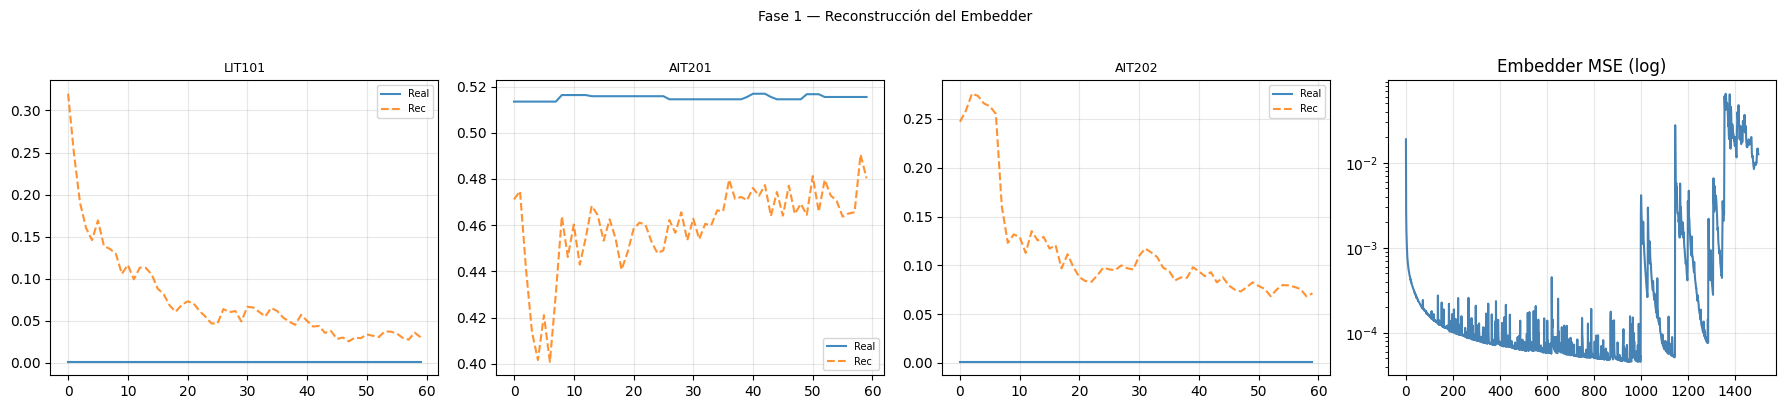

In [13]:
embedder_history = []
for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0)
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1:4d}/{epochs_embedder} | MSE: {ep:.6f}")

mse_f = embedder_history[-1]
print(f"\nMSE final: {mse_f:.6f}  {'✅' if mse_f < 0.001 else '⚠️ '}")

with torch.no_grad():
    xs = train_tensor[:64].to(device)
    xr = recovery(embedder(xs)).cpu().numpy()
    xo = xs.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx in range(3):
    axes[idx].plot(xo[0,:,idx], label="Real", alpha=0.85)
    axes[idx].plot(xr[0,:,idx], label="Rec",  alpha=0.85, linestyle="--")
    axes[idx].set_title(GAN_CONT_COLS[idx], fontsize=9)
    axes[idx].legend(fontsize=7); axes[idx].grid(True, alpha=0.3)
axes[3].semilogy(embedder_history, color="steelblue")
axes[3].set_title("Embedder MSE (log)"); axes[3].grid(True, alpha=0.3)
plt.suptitle("Fase 1 — Reconstrucción del Embedder", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()


## D1. Diagnóstico del Embedder — Calidad de Reconstrucción

=== D1: DIAGNOSTICO EMBEDDER — CALIDAD DE RECONSTRUCCION ===

Sensor                       MSE        RMSE  Estado
----------------------------------------------------
LIT101                  0.011156     0.10562  MAL
AIT201                  0.013080     0.11437  MAL
AIT202                  0.022509     0.15003  MAL
AIT203                  0.002747     0.05242  REVISAR
DPIT301                 0.027331     0.16532  MAL
LIT301                  0.007669     0.08758  REVISAR
AIT401                  0.006600     0.08124  REVISAR
AIT402                  0.003729     0.06106  REVISAR
LIT401                  0.011422     0.10687  MAL
AIT501                  0.008040     0.08967  REVISAR
AIT502                  0.005916     0.07692  REVISAR
AIT503                  0.021786     0.14760  MAL
AIT504                  0.009352     0.09671  REVISAR
PIT501                  0.007975     0.08930  REVISAR
PIT502                  0.022658     0.15053  MAL
PIT503                  0.008048     0.08971  REVI

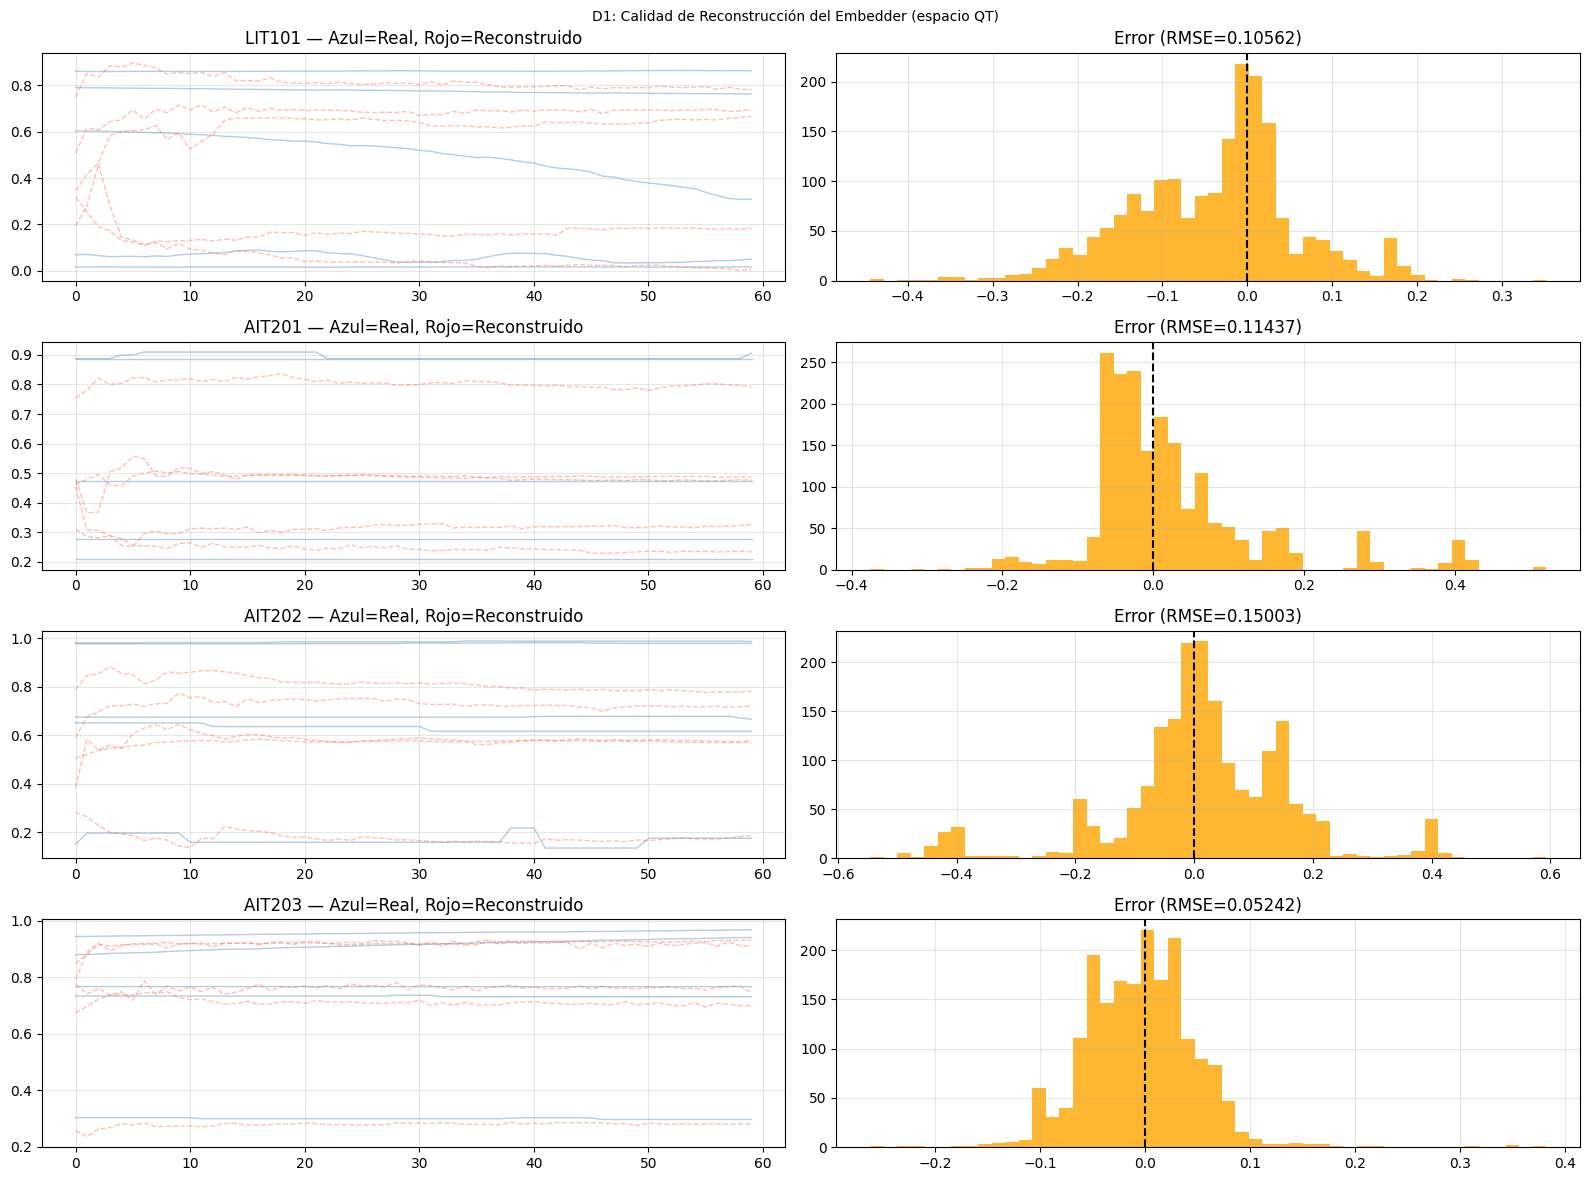

In [14]:
print("=== D1: DIAGNOSTICO EMBEDDER — CALIDAD DE RECONSTRUCCION ===")
print()
with torch.no_grad():
    x_samp = next(iter(train_loader))[0][:32].to(device)
    h_samp  = embedder(x_samp)
    x_rec   = recovery(h_samp).cpu().numpy()
x_samp_np = x_samp.cpu().numpy()
mse_per = ((x_samp_np - x_rec)**2).mean(axis=(0,1))

print(f'{"Sensor":<20}  {"MSE":>10}  {"RMSE":>10}  Estado')
print("-" * 52)
for j, s in enumerate(GAN_CONT_COLS):
    rmse = mse_per[j]**0.5
    est  = "OK" if rmse < 0.05 else ("REVISAR" if rmse < 0.10 else "MAL")
    print(f'{s:<20}  {mse_per[j]:>10.6f}  {rmse:>10.5f}  {est}')
print()
print(f"MSE global: {mse_per.mean():.6f} | RMSE global: {mse_per.mean()**0.5:.5f}")
print(f"Referencia A7 v21 MSE final: 0.000121")

plot_s = [s for s in GAN_CONT_COLS if any(k in s for k in ["LIT","AIT","PIT"])][:4]
if plot_s:
    fig, axes = plt.subplots(len(plot_s), 2, figsize=(16, 3*len(plot_s)))
    if len(plot_s) == 1: axes = [axes]
    for k, s in enumerate(plot_s):
        j = GAN_CONT_COLS.index(s)
        for w in range(min(5, 32)):
            axes[k][0].plot(x_samp_np[w,:,j], alpha=0.4, lw=1, color="steelblue")
            axes[k][0].plot(x_rec[w,:,j],     alpha=0.4, lw=1, color="tomato", linestyle="--")
        axes[k][0].set_title(f"{s} — Azul=Real, Rojo=Reconstruido"); axes[k][0].grid(True, alpha=0.3)
        diff = (x_samp_np[:,:,j] - x_rec[:,:,j]).flatten()
        axes[k][1].hist(diff, bins=50, color="orange", alpha=0.8)
        axes[k][1].axvline(0, color="black", lw=1.5, linestyle="--")
        axes[k][1].set_title(f"Error (RMSE={mse_per[j]**0.5:.5f})")
        axes[k][1].grid(True, alpha=0.3)
    plt.suptitle("D1: Calidad de Reconstrucción del Embedder (espacio QT)", fontsize=10)
    plt.tight_layout(); plt.show()


## 10b. Preentrenamiento del Generador (600 épocas) — kNN Assignment

Evita el cold-start del generador guiándolo hacia el espacio latente real
antes del entrenamiento adversarial.


=== PREENTRENAMIENTO DEL GENERADOR — kNN ASSIGNMENT ===

h_real_all: torch.Size([59136, 60, 128]) | h_real_mean: torch.Size([59136, 128])
[G Pretrain kNN] Epoch 100/600 | loss: 0.002306
[G Pretrain kNN] Epoch 200/600 | loss: 0.002329
[G Pretrain kNN] Epoch 300/600 | loss: 0.002448
[G Pretrain kNN] Epoch 400/600 | loss: 0.002317
[G Pretrain kNN] Epoch 500/600 | loss: 0.002401
[G Pretrain kNN] Epoch 600/600 | loss: 0.002441

kNN loss inicial: 0.004850 | final: 0.002441
Reducción: 49.7%


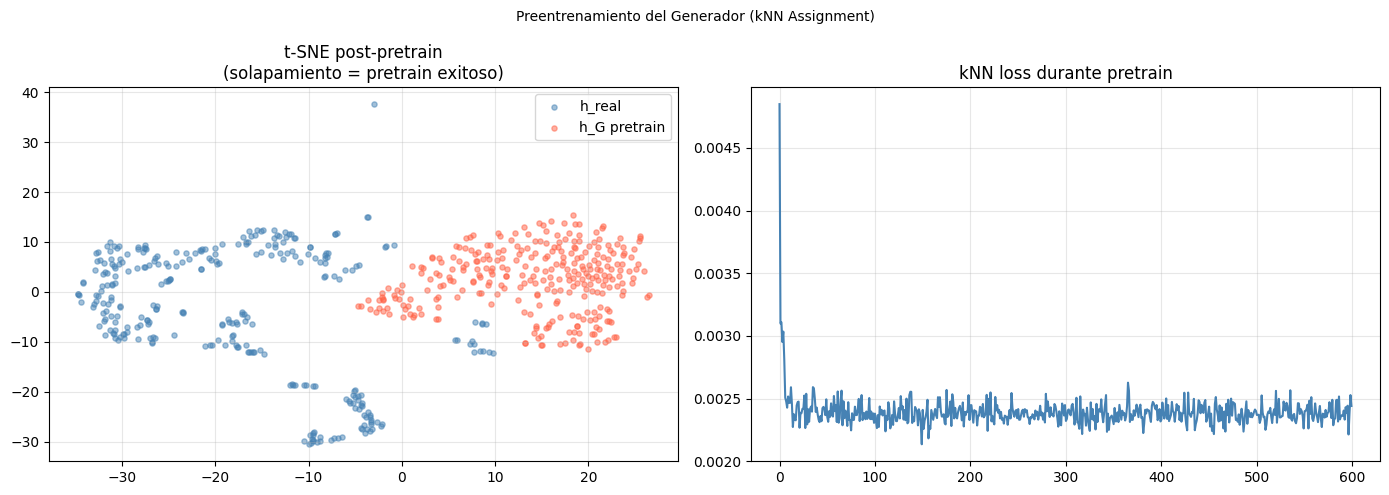

In [15]:
print("=== PREENTRENAMIENTO DEL GENERADOR — kNN ASSIGNMENT ===")
print()
h_real_all_list = []
with torch.no_grad():
    for batch in train_loader:
        x_b = batch[0].to(device)
        h_real_all_list.append(embedder(x_b).cpu())
h_real_all  = torch.cat(h_real_all_list, dim=0)
h_real_mean = h_real_all.mean(dim=1)
print(f"h_real_all: {h_real_all.shape} | h_real_mean: {h_real_mean.shape}")

gen_pretrain_opt = torch.optim.Adam(generator.parameters(), lr=5e-3)
pretrain_history = []
rng_pretrain = np.random.default_rng(99)

for epoch in range(GEN_PRETRAIN_EPOCHS):
    ep_loss = 0.0; n_batches = 0
    for start in range(0, len(h_real_mean), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(h_real_mean)); bs = end - start
        z         = random_z_clipped(bs, seq_len, latent_dim, device)
        h_hat_mean = generator(z).mean(dim=1)
        k_idx  = rng_pretrain.choice(len(h_real_mean), 64, replace=False)
        h_cand = h_real_mean[k_idx].to(device)
        dists  = ((h_hat_mean.unsqueeze(1) - h_cand.unsqueeze(0)) ** 2).mean(dim=-1)
        loss   = dists.min(dim=1).values.mean()
        gen_pretrain_opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), G_CLIP)
        gen_pretrain_opt.step()
        ep_loss += loss.item(); n_batches += 1
    ep_loss /= n_batches; pretrain_history.append(ep_loss)
    if (epoch + 1) % 100 == 0:
        print(f"[G Pretrain kNN] Epoch {epoch+1}/{GEN_PRETRAIN_EPOCHS} | loss: {ep_loss:.6f}")

print(f"\nkNN loss inicial: {pretrain_history[0]:.6f} | final: {pretrain_history[-1]:.6f}")
print(f"Reducción: {100*(pretrain_history[0]-pretrain_history[-1])/max(pretrain_history[0],1e-10):.1f}%")

# t-SNE post-pretrain
import warnings; from sklearn.manifold import TSNE as _TSNE2
n_check = 300; rng_check = np.random.default_rng(7)
idx_check = rng_check.choice(len(h_real_all), n_check, replace=False)
h_real_s  = h_real_all[idx_check].mean(dim=1).numpy()
with torch.no_grad():
    z_chk   = random_z_clipped(n_check, seq_len, latent_dim, device)
    h_pre_s = generator(z_chk).cpu().mean(dim=1).numpy()
H_pre = np.vstack([h_real_s, h_pre_s])
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    H_pre_2d = _TSNE2(n_components=2, perplexity=20, random_state=42, max_iter=500).fit_transform(H_pre)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(H_pre_2d[:n_check,0], H_pre_2d[:n_check,1], c="steelblue", alpha=0.5, s=14, label="h_real")
axes[0].scatter(H_pre_2d[n_check:,0], H_pre_2d[n_check:,1], c="tomato",    alpha=0.5, s=14, label="h_G pretrain")
axes[0].set_title("t-SNE post-pretrain\n(solapamiento = pretrain exitoso)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(pretrain_history, color="steelblue", lw=1.5)
axes[1].set_title("kNN loss durante pretrain"); axes[1].grid(True, alpha=0.3)
plt.suptitle("Preentrenamiento del Generador (kNN Assignment)", fontsize=10)
plt.tight_layout(); plt.show()


## 11. Fase 2 — Preentrenamiento del Supervisor (600 épocas)

In [16]:
supervisor_history = []
for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad(): h = embedder(x)
        hs   = supervisor(h)
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1:4d}/{epochs_supervisor} | Loss: {ep:.6f}")
sup_f = supervisor_history[-1]
print(f"\nLoss final: {sup_f:.6f}  {'✅' if sup_f < 0.005 else '⚠️ '}")


[Supervisor] Epoch  100/600 | Loss: 0.014818
[Supervisor] Epoch  200/600 | Loss: 0.014659
[Supervisor] Epoch  300/600 | Loss: 0.014588
[Supervisor] Epoch  400/600 | Loss: 0.014532
[Supervisor] Epoch  500/600 | Loss: 0.014498
[Supervisor] Epoch  600/600 | Loss: 0.014466

Loss final: 0.014466  ⚠️ 


## D2. Diagnóstico del Supervisor — Predicción Temporal

=== D2: DIAGNOSTICO SUPERVISOR — PREDICCION TEMPORAL ===
Teacher-forced MSE: 0.014616
Free-run MSE:       0.026502
Ratio free/tf:      1.81x
Supervisor: EXCELENTE generalización temporal


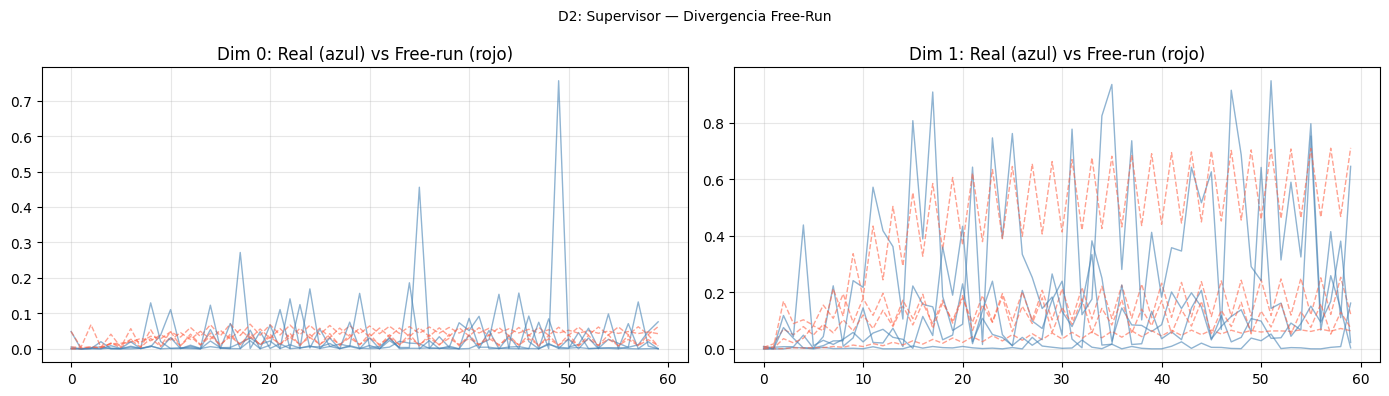

In [17]:
print("=== D2: DIAGNOSTICO SUPERVISOR — PREDICCION TEMPORAL ===")
with torch.no_grad():
    x_b = next(iter(train_loader))[0][:16].to(device)
    h_b = embedder(x_b)
    h_pred_tf = supervisor(h_b)
    tf_loss   = ((h_b[:, 1:, :] - h_pred_tf[:, :-1, :])**2).mean().item()
    h_seq = h_b[:, :1, :]; preds = [h_seq]
    for _ in range(seq_len - 1):
        h_next = supervisor(h_seq)[:, -1:, :]; preds.append(h_next)
        h_seq  = torch.cat([h_seq, h_next], dim=1)
    h_free    = torch.cat(preds, dim=1)
    free_loss = ((h_b[:, 1:, :] - h_free[:, 1:, :])**2).mean().item()
ratio = free_loss / max(tf_loss, 1e-10)
print(f"Teacher-forced MSE: {tf_loss:.6f}")
print(f"Free-run MSE:       {free_loss:.6f}")
print(f"Ratio free/tf:      {ratio:.2f}x")
if ratio < 5:    print("Supervisor: EXCELENTE generalización temporal")
elif ratio < 15: print("Supervisor: ACEPTABLE generalización")
else:            print("Supervisor: ALERTA — alta divergencia en free-run")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
h_b_np = h_b.cpu().numpy(); h_free_np = h_free.cpu().numpy()
for w in range(4):
    axes[0].plot(h_b_np[w,:,0], alpha=0.6, lw=1, color="steelblue")
    axes[0].plot(h_free_np[w,:,0], alpha=0.6, lw=1, color="tomato", linestyle="--")
axes[0].set_title("Dim 0: Real (azul) vs Free-run (rojo)"); axes[0].grid(True, alpha=0.3)
for w in range(4):
    axes[1].plot(h_b_np[w,:,1], alpha=0.6, lw=1, color="steelblue")
    axes[1].plot(h_free_np[w,:,1], alpha=0.6, lw=1, color="tomato", linestyle="--")
axes[1].set_title("Dim 1: Real (azul) vs Free-run (rojo)"); axes[1].grid(True, alpha=0.3)
plt.suptitle("D2: Supervisor — Divergencia Free-Run", fontsize=10)
plt.tight_layout(); plt.show()


## 12. Fase 3 — Entrenamiento adversarial conjunto (2000 épocas)

Idéntico a A12 v18: R1 lazy, feature matching, G_STEPS=2, D_STEPS=2.


In [18]:
def r1_penalty(disc, h_real):
    h_r  = h_real.detach().requires_grad_(True)
    y_r  = disc(h_r)
    grad = torch.autograd.grad(outputs=y_r.sum(), inputs=h_r,
                                create_graph=False, retain_graph=False)[0]
    return grad.pow(2).mean()

joint_g_history, joint_d_history, joint_e_history = [], [], []
batch_counter = 0

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0
    for batch in train_loader:
        x  = batch[0].to(device); bs = x.shape[0]
        with torch.no_grad(): h_real = embedder(x)

        # G_STEPS
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()
            z     = random_z_clipped(bs, seq_len, latent_dim, device)
            e_hat = generator(z); h_hat = supervisor(e_hat)
            y_f   = discriminator(h_hat); y_fe = discriminator(e_hat)
            g_u   = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue  = bce_loss(y_fe, torch.ones_like(y_fe))
            with torch.no_grad(): h_sup = supervisor(h_real)
            g_s     = mse_loss(h_real[:, 1:, :].detach(), h_sup[:, :-1, :])
            fm_loss = (mse_loss(h_hat.mean(0), h_real.mean(0)) +
                       mse_loss(h_hat.std(0),  h_real.std(0)))
            g_loss  = g_u + gamma * g_ue + eta * g_s + FM_W * fm_loss
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), G_CLIP)
            g_optimizer.step(); g_loss_val = g_loss

        # Embedder refinement
        e_optimizer.zero_grad()
        h_ref   = embedder(x); x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :])
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0)
        e_optimizer.step()
        batch_counter += 1

        # D_STEPS con R1 lazy
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()
            with torch.no_grad():
                z2     = random_z_clipped(bs, seq_len, latent_dim, device)
                e_hat2 = generator(z2); h_hat2 = supervisor(e_hat2)
            y_r   = discriminator(h_real)
            y_f2  = discriminator(h_hat2); y_fe2 = discriminator(e_hat2)
            r1 = (
                r1_penalty(discriminator, h_real)
                if batch_counter % R1_INTERVAL == 0
                else torch.tensor(0.0, device=device)
            )
            d_loss = (bce_loss(y_r,   torch.ones_like(y_r)) +
                      bce_loss(y_f2,  torch.zeros_like(y_f2)) +
                      gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2)) +
                      R1_LAMBDA * R1_INTERVAL * r1)
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), D_CLIP)
            d_optimizer.step(); d_loss_val = d_loss

        g_ep += g_loss_val.item(); d_ep += d_loss_val.item(); e_ep += e_loss.item()

    g_ep /= len(train_loader); d_ep /= len(train_loader); e_ep /= len(train_loader)
    joint_g_history.append(g_ep); joint_d_history.append(d_ep); joint_e_history.append(e_ep)
    g_scheduler.step(g_ep); d_scheduler.step(d_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev-0.05 else ("↑" if g_ep > g_prev+0.1 else "→")
        print(f"[Joint] Epoch {epoch+1:5d}/{epochs_joint} | "
              f"G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f}")


[Joint] Epoch   100/2000 | G: 6.0713↑ | D: 1.5528 | E: 0.028979
[Joint] Epoch   200/2000 | G: 8.6826↑ | D: 0.4848 | E: 0.006234
[Joint] Epoch   300/2000 | G: 11.3510↑ | D: 0.7871 | E: 0.008365
[Joint] Epoch   400/2000 | G: 11.7676↑ | D: 1.2422 | E: 0.024588
[Joint] Epoch   500/2000 | G: 15.4346↑ | D: 3.3079 | E: 0.019032
[Joint] Epoch   600/2000 | G: 10.9400↓ | D: 3.2952 | E: 0.027544
[Joint] Epoch   700/2000 | G: 11.1307↑ | D: 5.7059 | E: 0.025540
[Joint] Epoch   800/2000 | G: 10.5198↓ | D: 7.5153 | E: 0.010807
[Joint] Epoch   900/2000 | G: 9.0320↓ | D: 3.8535 | E: 0.013862
[Joint] Epoch  1000/2000 | G: 9.7022↑ | D: 3.6082 | E: 0.011579
[Joint] Epoch  1100/2000 | G: 11.0641↑ | D: 1.9987 | E: 0.017851
[Joint] Epoch  1200/2000 | G: 9.2666↓ | D: 1.2816 | E: 0.019947
[Joint] Epoch  1300/2000 | G: 9.0698↓ | D: 1.6424 | E: 0.016611
[Joint] Epoch  1400/2000 | G: 8.3048↓ | D: 2.2003 | E: 0.015353
[Joint] Epoch  1500/2000 | G: 8.2796→ | D: 1.5926 | E: 0.014350
[Joint] Epoch  1600/2000 | G: 11.

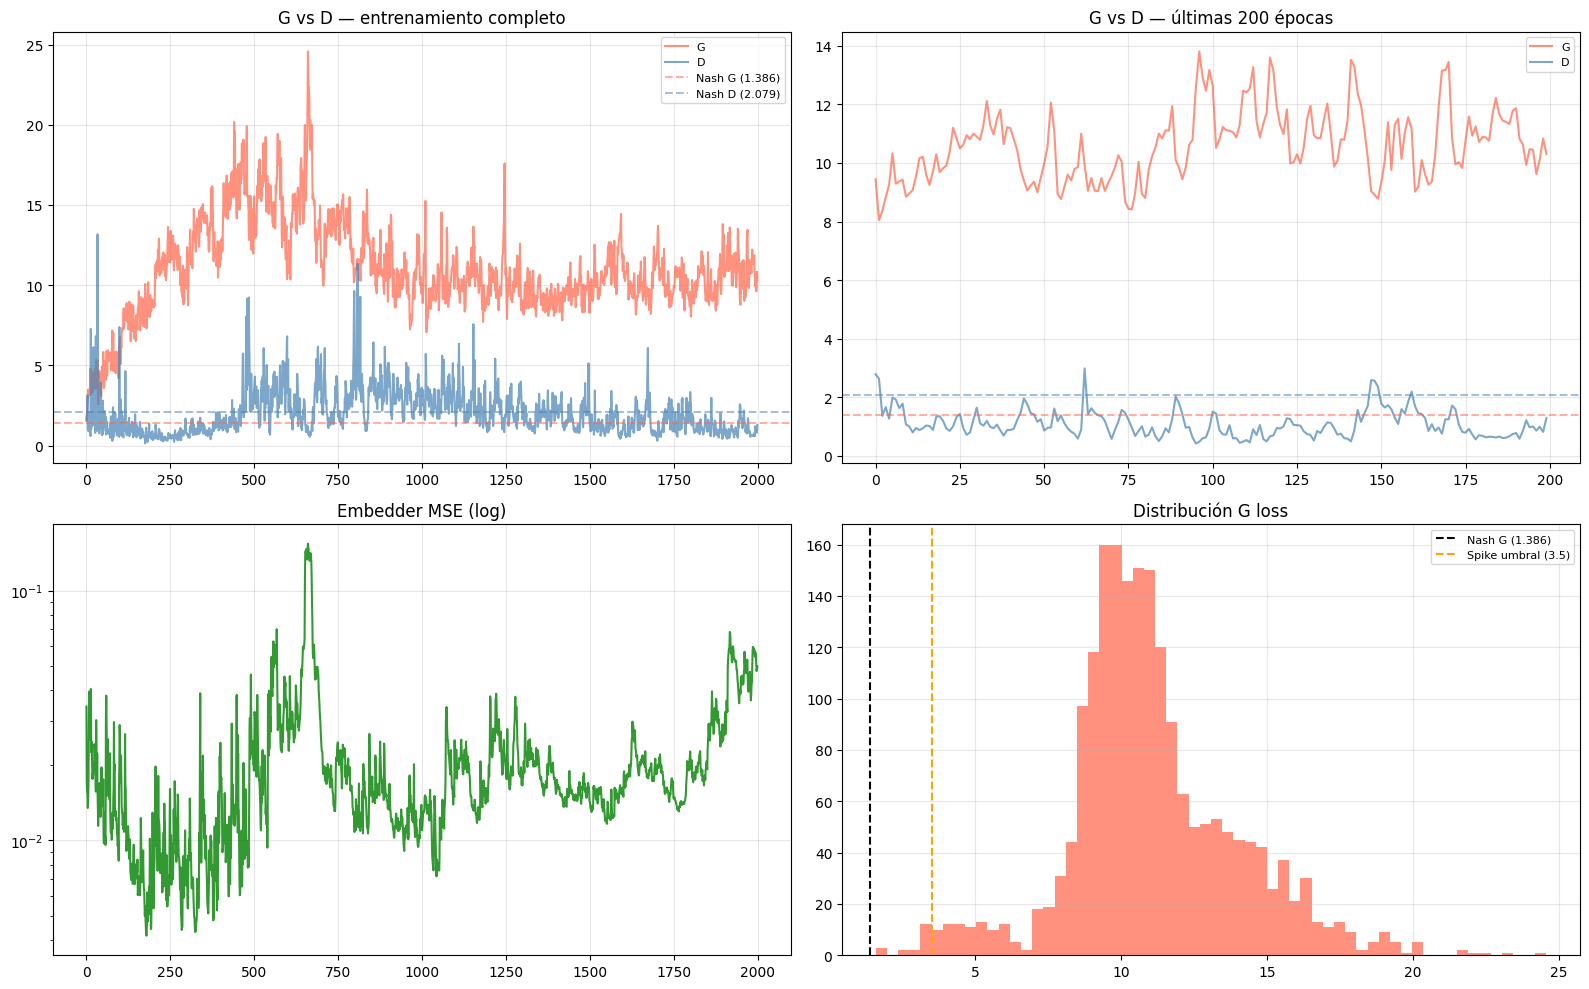

G inicial:    1.8253  (Nash G=1.3863)
G final:      10.3051
D final:      1.2929  (Nash D = 2.0794, gap=0.7865)
Spikes G>3.5: 1981


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(joint_g_history, alpha=0.7, color="tomato",    label="G")
axes[0,0].plot(joint_d_history, alpha=0.7, color="steelblue", label="D")
axes[0,0].axhline(nash_g, color="tomato",    linestyle="--", alpha=0.5, label=f"Nash G ({nash_g:.3f})")
axes[0,0].axhline(nash_d, color="steelblue", linestyle="--", alpha=0.5, label=f"Nash D ({nash_d:.3f})")
axes[0,0].set_title("G vs D — entrenamiento completo"); axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(joint_g_history[-200:], alpha=0.7, color="tomato",    label="G")
axes[0,1].plot(joint_d_history[-200:], alpha=0.7, color="steelblue", label="D")
axes[0,1].axhline(nash_g, color="tomato", linestyle="--", alpha=0.5)
axes[0,1].axhline(nash_d, color="steelblue", linestyle="--", alpha=0.5)
axes[0,1].set_title("G vs D — últimas 200 épocas"); axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)
axes[1,0].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1,0].set_title("Embedder MSE (log)"); axes[1,0].grid(True, alpha=0.3)
axes[1,1].hist(joint_g_history, bins=60, color="tomato", alpha=0.7)
axes[1,1].axvline(nash_g, color="black",  linestyle="--", lw=1.5, label=f"Nash G ({nash_g:.3f})")
axes[1,1].axvline(3.5,    color="orange", linestyle="--", lw=1.5, label="Spike umbral (3.5)")
axes[1,1].set_title("Distribución G loss"); axes[1,1].legend(fontsize=8); axes[1,1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

g_f = joint_g_history[-1]; d_f = joint_d_history[-1]
spikes = sum(1 for g in joint_g_history if g > 3.5)
print(f"G inicial:    {joint_g_history[0]:.4f}  (Nash G={nash_g:.4f})")
print(f"G final:      {g_f:.4f}")
print(f"D final:      {d_f:.4f}  (Nash D = {nash_d:.4f}, gap={abs(d_f-nash_d):.4f})")
print(f"Spikes G>3.5: {spikes}")


## D3. Diagnóstico del Generador — t-SNE del Espacio Latente

=== D3: DIAGNOSTICO GENERADOR — t-SNE ESPACIO LATENTE ===


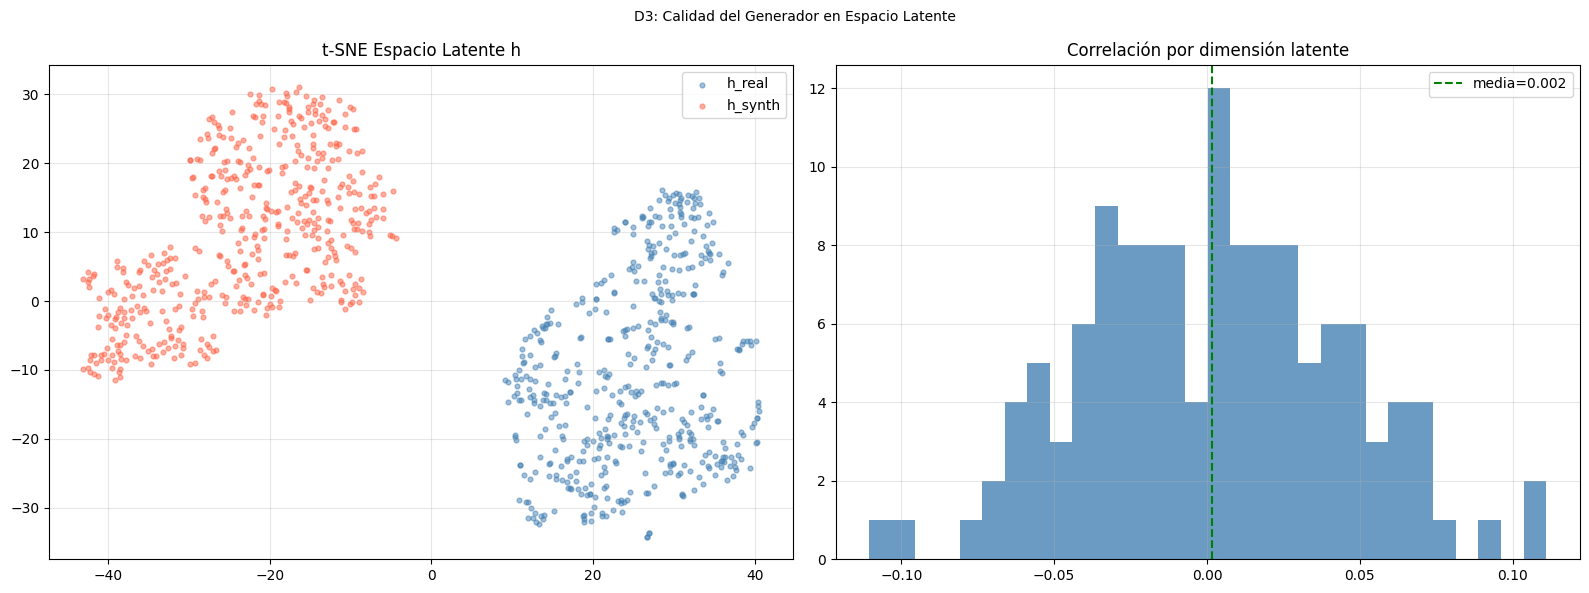

In [20]:
import warnings; from sklearn.manifold import TSNE as _TSNE
print("=== D3: DIAGNOSTICO GENERADOR — t-SNE ESPACIO LATENTE ===")
n_lat = 500; rng_l = np.random.default_rng(42)
idx_l = rng_l.choice(len(train_windows), n_lat, replace=False)
with torch.no_grad():
    x_r = torch.tensor(train_windows[idx_l], dtype=torch.float32).to(device)
    h_r = embedder(x_r).cpu().numpy()
    z_s = random_z_clipped(n_lat, seq_len, latent_dim, device)
    h_s = supervisor(generator(z_s)).cpu().numpy()
hr_mp = h_r.mean(axis=1); hs_mp = h_s.mean(axis=1)
H_all = np.vstack([hr_mp, hs_mp]); y_all_lat = np.array([0]*n_lat + [1]*n_lat)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    H2d = _TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(H_all)
corr_dims = [np.corrcoef(hr_mp[:,d], hs_mp[:,d])[0,1] for d in range(hr_mp.shape[1])]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(H2d[y_all_lat==0,0], H2d[y_all_lat==0,1], c="steelblue", alpha=0.5, s=12, label="h_real")
axes[0].scatter(H2d[y_all_lat==1,0], H2d[y_all_lat==1,1], c="tomato",    alpha=0.5, s=12, label="h_synth")
axes[0].set_title("t-SNE Espacio Latente h"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].hist(corr_dims, bins=30, color="steelblue", alpha=0.8)
axes[1].axvline(np.mean(corr_dims), color="green", linestyle="--", lw=1.5,
                label=f"media={np.mean(corr_dims):.3f}")
axes[1].set_title("Correlación por dimensión latente"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle("D3: Calidad del Generador en Espacio Latente", fontsize=10)
plt.tight_layout(); plt.show()


## 13. Generación de datos sintéticos (espacio QT)

In [21]:
n_synth = len(train_windows)
synth_qt_list = []
with torch.no_grad():
    for start in range(0, n_synth, 256):
        end = min(start + 256, n_synth); bs = end - start
        z      = random_z_clipped(bs, seq_len, latent_dim, device)
        x_hat  = recovery(supervisor(generator(z))).cpu().numpy()
        synth_qt_list.append(x_hat)
synth_qt = np.concatenate(synth_qt_list, axis=0)

out_rng = ((synth_qt < -0.1) | (synth_qt > 1.1)).mean() * 100
print(f"synth_qt shape: {synth_qt.shape}")
print(f"Rango pre-clip: [{synth_qt.min():.4f}, {synth_qt.max():.4f}]")
print(f"Fuera de [-0.1, 1.1]: {out_rng:.2f}%  {'✅' if out_rng < 1.0 else '⚠️'}")
synth_qt_clipped = np.clip(synth_qt, 0.0, 1.0)
dm = abs(train_windows.mean() - synth_qt_clipped.mean())
ds = abs(train_windows.std()  - synth_qt_clipped.std())
print(f"Diff medias QT (pre-QM): {dm:.4f}  {'✅' if dm<0.05 else '⚠️'}")
print(f"Diff stds  QT (pre-QM): {ds:.4f}  {'✅' if ds<0.10 else '⚠️'}")


synth_qt shape: (59173, 60, 16)
Rango pre-clip: [-0.1252, 1.1516]
Fuera de [-0.1, 1.1]: 0.00%  ✅
Diff medias QT (pre-QM): 0.1151  ⚠️
Diff stds  QT (pre-QM): 0.1015  ⚠️


## D4. Diagnóstico Pre-QM — Drift por Sensor

=== D4: DIAGNOSTICO PRE-QM POR SENSOR ===

Sensor                     dm       ds    ratio  Estado
-------------------------------------------------------
LIT101                 0.0691   0.2503     0.74x  MAL
AIT201                 0.1665   0.1854     5.78x  MAL
AIT202                 0.2833   0.2414     0.59x  MAL
AIT203                 0.0422   0.2613     1.69x  MAL
DPIT301                0.2042   0.2157     0.30x  MAL
LIT301                 0.1877   0.2356     1.26x  MAL
AIT401                 0.2979   0.2770     1.16x  MAL
AIT402                 0.0471   0.2459     2.44x  MAL
LIT401                 0.2928   0.2336     2.12x  MAL
AIT501                 0.0090   0.2190     1.77x  MAL
AIT502                 0.0246   0.2081     2.61x  MAL
AIT503                 0.1714   0.1582     3.51x  MAL
AIT504                 0.1071   0.1927     0.53x  MAL
PIT501                 0.3199   0.2124     0.49x  MAL
PIT502                 0.2698   0.2150     0.37x  MAL
PIT503                 0.3305   0.2

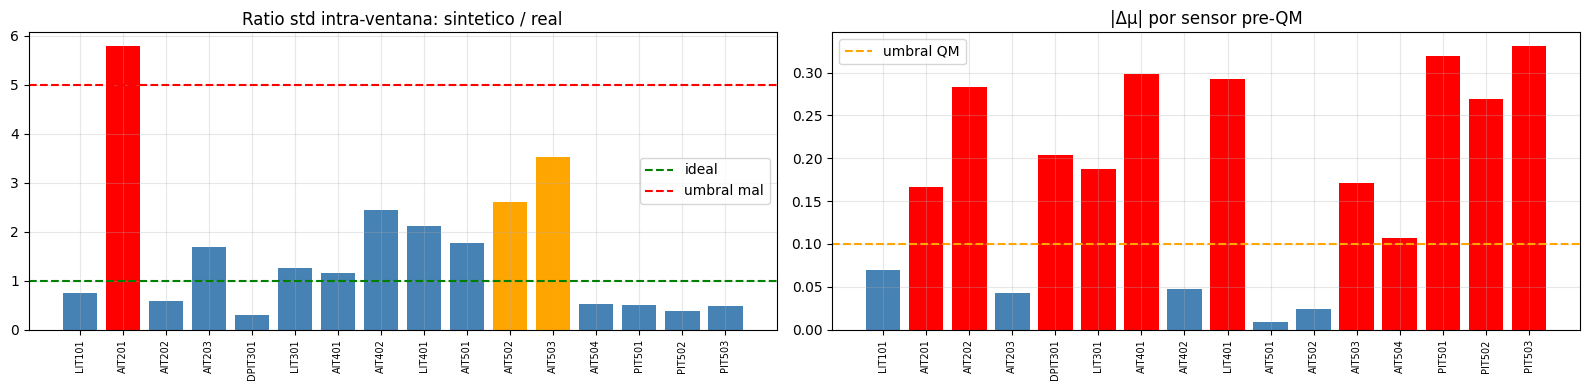

In [22]:
print("=== D4: DIAGNOSTICO PRE-QM POR SENSOR ==="); print()
_rf = train_windows.reshape(-1, len(GAN_CONT_COLS))
_sf = synth_qt_clipped.reshape(-1, len(GAN_CONT_COLS))
dm_p = np.abs(_rf.mean(0) - _sf.mean(0)); ds_p = np.abs(_rf.std(0) - _sf.std(0))
intra_r = train_windows.std(axis=1).mean(axis=0)
intra_s = synth_qt_clipped.std(axis=1).mean(axis=0)
ratio_i = intra_s / np.maximum(intra_r, 1e-8)
print(f'{"Sensor":<20}  {"dm":>7}  {"ds":>7}  {"ratio":>7}  Estado')
print("-" * 55)
for j, s in enumerate(GAN_CONT_COLS):
    if dm_p[j]>0.10 or ds_p[j]>0.15 or ratio_i[j]>5.0:  est = "MAL"
    elif dm_p[j]>0.05 or ds_p[j]>0.08 or ratio_i[j]>2.5: est = "REVISAR"
    else:                                                    est = "OK"
    print(f'{s:<20}  {dm_p[j]:>7.4f}  {ds_p[j]:>7.4f}  {ratio_i[j]:>7.2f}x  {est}')
n_mal = sum(1 for j in range(len(GAN_CONT_COLS)) if dm_p[j]>0.10 or ds_p[j]>0.15 or ratio_i[j]>5.0)
print(f"\nSensores MAL: {n_mal}/{len(GAN_CONT_COLS)} | dm global: {dm_p.mean():.4f}")
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
colors_b = ["red" if r>5 else ("orange" if r>2.5 else "steelblue") for r in ratio_i]
axes[0].bar(range(len(GAN_CONT_COLS)), ratio_i, color=colors_b)
axes[0].axhline(1.0, color="green",  linestyle="--", lw=1.5, label="ideal")
axes[0].axhline(5.0, color="red",    linestyle="--", lw=1.5, label="umbral mal")
axes[0].set_xticks(range(len(GAN_CONT_COLS)))
axes[0].set_xticklabels([s.replace(".Pv","") for s in GAN_CONT_COLS], rotation=90, fontsize=7)
axes[0].set_title("Ratio std intra-ventana: sintetico / real"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].bar(range(len(GAN_CONT_COLS)), dm_p, color=["red" if d>0.1 else "steelblue" for d in dm_p])
axes[1].axhline(0.10, color="orange", linestyle="--", lw=1.5, label="umbral QM")
axes[1].set_xticks(range(len(GAN_CONT_COLS)))
axes[1].set_xticklabels([s.replace(".Pv","") for s in GAN_CONT_COLS], rotation=90, fontsize=7)
axes[1].set_title("|Δμ| por sensor pre-QM"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 13b. Corrección de distribución marginal — Quantile Mapping

In [23]:
from scipy.stats import rankdata
CORR_MEAN_THR = 0.10; CORR_STD_THR = 0.15
_real_flat_pre  = train_windows.reshape(-1, len(GAN_CONT_COLS))
_synth_flat_pre = synth_qt_clipped.reshape(-1, len(GAN_CONT_COLS))
_dm_pre = np.abs(_real_flat_pre.mean(0) - _synth_flat_pre.mean(0))
_ds_pre = np.abs(_real_flat_pre.std(0)  - _synth_flat_pre.std(0))
CORRECTION_SENSORS = [GAN_CONT_COLS[j] for j in range(len(GAN_CONT_COLS))
                      if _dm_pre[j] > CORR_MEAN_THR or _ds_pre[j] > CORR_STD_THR]
print(f"Sensores para corrección: {len(CORRECTION_SENSORS)} / {len(GAN_CONT_COLS)}")
print(f"  {CORRECTION_SENSORS}")

def quantile_mapping(synth_col_flat, real_col_flat):
    real_sorted = np.sort(real_col_flat); n_real = len(real_sorted)
    ranks = rankdata(synth_col_flat, method="ordinal") - 1
    n_s   = len(synth_col_flat)
    idx   = np.clip((ranks / max(n_s-1,1) * (n_real-1)).astype(int), 0, n_real-1)
    return real_sorted[idx].astype(np.float32)

synth_qt_corrected = synth_qt_clipped.copy()
for sensor in CORRECTION_SENSORS:
    j = GAN_CONT_COLS.index(sensor)
    real_flat_col  = train_windows[:,:,j].flatten()
    synth_flat_col = synth_qt_corrected[:,:,j].flatten()
    dm_b = abs(real_flat_col.mean() - synth_flat_col.mean())
    corrected_flat = quantile_mapping(synth_flat_col, real_flat_col)
    synth_qt_corrected[:,:,j] = corrected_flat.reshape(synth_qt_clipped.shape[0], synth_qt_clipped.shape[1])
    dm_a = abs(real_flat_col.mean() - corrected_flat.mean())
    print(f"{sensor}: |dm| {dm_b:.4f} → {dm_a:.6f}")

_real_f = train_windows.reshape(-1, len(GAN_CONT_COLS)); _corr_f = synth_qt_corrected.reshape(-1, len(GAN_CONT_COLS))
print(f"\nDiff medias QT global — antes: {np.abs(_real_flat_pre.mean(0)-_synth_flat_pre.mean(0)).mean():.4f}"
      f"  | después: {np.abs(_real_f.mean(0)-_corr_f.mean(0)).mean():.4f}")


Sensores para corrección: 16 / 16
  ['LIT101', 'AIT201', 'AIT202', 'AIT203', 'DPIT301', 'LIT301', 'AIT401', 'AIT402', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'PIT501', 'PIT502', 'PIT503']
LIT101: |dm| 0.0699 → 0.000000
AIT201: |dm| 0.1680 → 0.000000
AIT202: |dm| 0.2842 → 0.000000
AIT203: |dm| 0.0493 → 0.000000
DPIT301: |dm| 0.2007 → 0.000000
LIT301: |dm| 0.1802 → 0.000000
AIT401: |dm| 0.3173 → 0.000000
AIT402: |dm| 0.0496 → 0.000000
LIT401: |dm| 0.3028 → 0.000000
AIT501: |dm| 0.0076 → 0.000000
AIT502: |dm| 0.0256 → 0.000000
AIT503: |dm| 0.1712 → 0.000000
AIT504: |dm| 0.1057 → 0.000000
PIT501: |dm| 0.3219 → 0.000000
PIT502: |dm| 0.2746 → 0.000000
PIT503: |dm| 0.3312 → 0.000000

Diff medias QT global — antes: 0.1764  | después: 0.0008


## 13c. Iman-Conover Correlation Remapping

=== IMAN-CONOVER CORRELATION REMAPPING ===

Diff media correlaciones: antes=0.2757  -> después=0.0076
Mejora: 97.2%


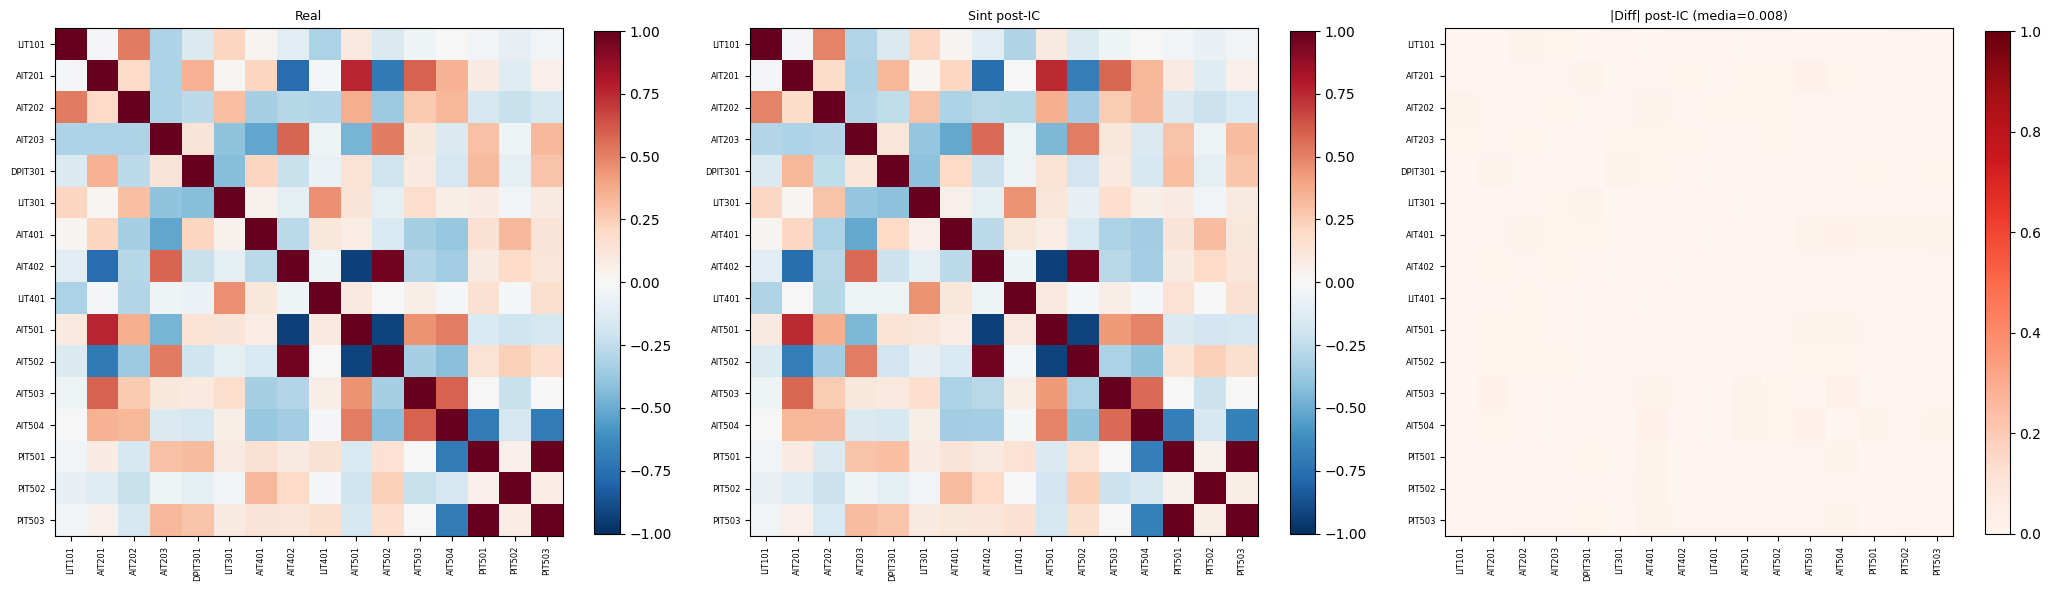

synth_qt_corrected actualizado con Iman-Conover.


In [24]:
from scipy.stats import rankdata as sp_rankdata
print("=== IMAN-CONOVER CORRELATION REMAPPING ==="); print()
N_ic, T_ic, F_ic = synth_qt_corrected.shape
synth_wmean = synth_qt_corrected.mean(axis=1); real_wmean = train_windows.mean(axis=1)
C_real_ic = np.corrcoef(real_wmean.T); C_real_ic = (C_real_ic + C_real_ic.T) / 2
jitter = 1e-6
for _ in range(10):
    try: L_ic = np.linalg.cholesky(C_real_ic + jitter * np.eye(F_ic)); break
    except np.linalg.LinAlgError: jitter *= 10
rng_ic = np.random.default_rng(42); Z_ic = rng_ic.standard_normal((N_ic, F_ic)); Z_corr = Z_ic @ L_ic.T
synth_qt_ic = np.zeros_like(synth_qt_corrected)
for j in range(F_ic):
    target_rank  = sp_rankdata(Z_corr[:,j], method="ordinal").astype(int) - 1
    order_current = np.argsort(synth_wmean[:,j])
    source_windows = order_current[target_rank]
    synth_qt_ic[:,:,j] = synth_qt_corrected[source_windows,:,j]
synth_wmean_after = synth_qt_ic.mean(axis=1)
C_synth_before = np.corrcoef(synth_wmean.T); C_synth_after = np.corrcoef(synth_wmean_after.T)
diff_before = np.abs(C_real_ic - C_synth_before).mean(); diff_after = np.abs(C_real_ic - C_synth_after).mean()
print(f"Diff media correlaciones: antes={diff_before:.4f}  -> después={diff_after:.4f}")
print(f"Mejora: {100*(diff_before-diff_after)/max(diff_before,1e-10):.1f}%")
labs_ic = [s.replace(".Pv","") for s in GAN_CONT_COLS]
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, data, title in zip(axes, [C_real_ic, C_synth_after, np.abs(C_real_ic-C_synth_after)],
                             ["Real", "Sint post-IC", f"|Diff| post-IC (media={diff_after:.3f})"]):
    vmin, vmax = (-1,1) if "Diff" not in title else (0,1)
    cmap = "RdBu_r" if "Diff" not in title else "Reds"
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(F_ic)); ax.set_xticklabels(labs_ic, rotation=90, fontsize=6)
    ax.set_yticks(range(F_ic)); ax.set_yticklabels(labs_ic, fontsize=6)
    plt.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout(); plt.show()
synth_qt_corrected = synth_qt_ic
print("synth_qt_corrected actualizado con Iman-Conover.")


## D5. Diagnóstico Post-QM — Matriz de Correlación Cruzada

=== D5: MATRIZ DE CORRELACION CRUZADA REAL vs SINTETICO ===



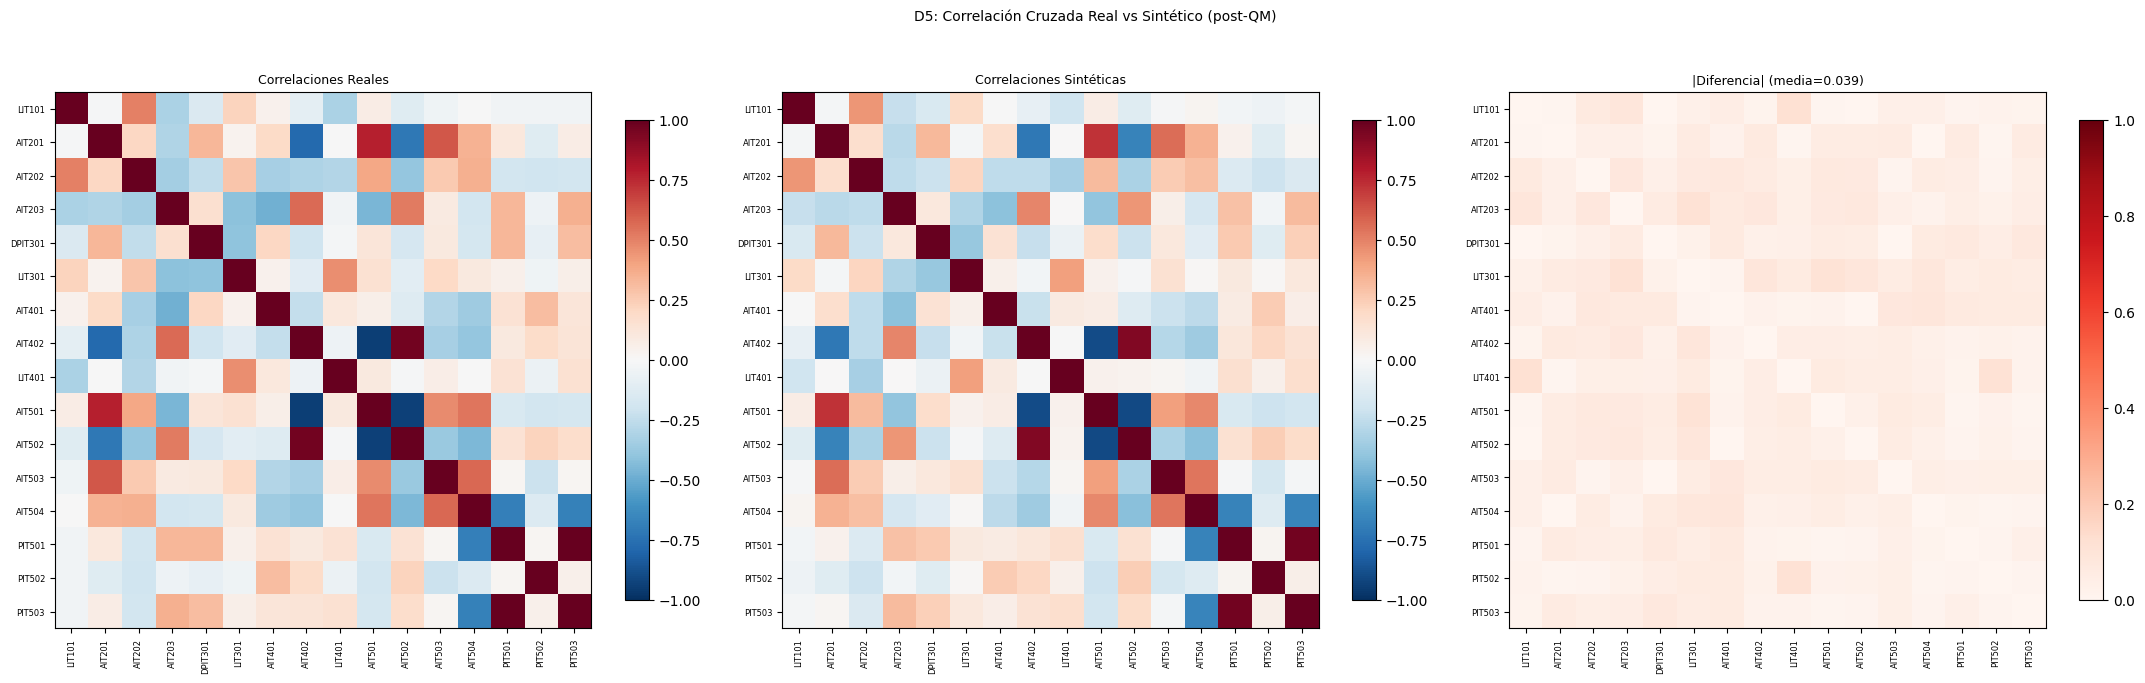

Diferencia media: 0.0389  (ideal: < 0.10)
Diferencia máxima: 0.1201


In [25]:
print("=== D5: MATRIZ DE CORRELACION CRUZADA REAL vs SINTETICO ==="); print()
n_cc = min(2000, len(train_windows)); rng_cc = np.random.default_rng(99)
idx_cc = rng_cc.choice(len(train_windows), n_cc, replace=False)
real_cc  = train_windows[idx_cc].reshape(-1, len(GAN_CONT_COLS))
synth_cc = synth_qt_corrected[idx_cc].reshape(-1, len(GAN_CONT_COLS))
corr_r = np.corrcoef(real_cc.T); corr_s = np.corrcoef(synth_cc.T); corr_d = np.abs(corr_r - corr_s)
labs = [s.replace(".Pv","") for s in GAN_CONT_COLS]
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, data, title in zip(axes, [corr_r, corr_s, corr_d],
    ["Correlaciones Reales","Correlaciones Sintéticas",f"|Diferencia| (media={corr_d.mean():.3f})"]):
    vmin, vmax = (-1,1) if "Diferencia" not in title else (0,1)
    cmap = "RdBu_r" if "Diferencia" not in title else "Reds"
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=90, fontsize=6)
    ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=6)
    plt.colorbar(im, ax=ax, shrink=0.75)
plt.suptitle("D5: Correlación Cruzada Real vs Sintético (post-QM)", fontsize=10)
plt.tight_layout(); plt.show()
print(f"Diferencia media: {corr_d.mean():.4f}  (ideal: < 0.10)")
print(f"Diferencia máxima: {corr_d.max():.4f}")


## 13d. Detrending Soft — LIT, AIT, PIT

In [26]:
from scipy.signal import detrend as scipy_detrend
SLOW_SENSORS_QT = [s for s in GAN_CONT_COLS if s.startswith("LIT") or s.startswith("AIT") or s.startswith("PIT")]
real_intra_std_qt = {s: float(train_windows[:,:,GAN_CONT_COLS.index(s)].std(axis=1).mean()) for s in SLOW_SENSORS_QT}
print(f"=== DETRENDING SOFT ({len(SLOW_SENSORS_QT)} sensores) ===")
synth_qt_detrended = synth_qt_corrected.copy()
windows_intervened = {s: 0 for s in SLOW_SENSORS_QT}
for s in SLOW_SENSORS_QT:
    j = GAN_CONT_COLS.index(s)
    target_std = real_intra_std_qt[s]; threshold = DETREND_FACTOR * target_std; rescale_to = DETREND_TARGET * target_std
    for w in range(synth_qt_detrended.shape[0]):
        win = synth_qt_detrended[w,:,j].copy()
        if win.std() > threshold:
            win_mean = win.mean(); detrended = scipy_detrend(win); curr_std = detrended.std()
            if curr_std > 1e-8: detrended = detrended * (rescale_to / curr_std)
            synth_qt_detrended[w,:,j] = np.clip(detrended + win_mean, 0.0, 1.0)
            windows_intervened[s] += 1
total_w = synth_qt_detrended.shape[0]
print(f'{"Sensor":<20}  {"real_std":>9}  {"synth_post":>12}  {"ratio":>7}  {"intervenidas":>14}')
print("-" * 70)
for s in SLOW_SENSORS_QT:
    j = GAN_CONT_COLS.index(s)
    synth_post = float(synth_qt_detrended[:,:,j].std(axis=1).mean())
    ratio = synth_post / max(real_intra_std_qt[s], 1e-8)
    n_int = windows_intervened[s]
    print(f'{s:<20}  {real_intra_std_qt[s]:>9.5f}  {synth_post:>12.5f}  {ratio:>7.3f}  {n_int:>6}/{total_w}')
synth_qt_corrected = synth_qt_detrended
print("\nsynth_qt_corrected actualizado con detrending soft.")


=== DETRENDING SOFT (15 sensores) ===
Sensor                 real_std    synth_post    ratio    intervenidas
----------------------------------------------------------------------
LIT101                  0.01561       0.02430    1.557   47919/59173
AIT201                  0.00328       0.00496    1.511   57472/59173
AIT202                  0.02580       0.04234    1.641   36809/59173
AIT203                  0.00641       0.00958    1.496   57091/59173
LIT301                  0.00977       0.01463    1.497   53144/59173
AIT401                  0.01296       0.01820    1.404   53744/59173
AIT402                  0.00410       0.00621    1.513   56260/59173
LIT401                  0.01075       0.01614    1.501   55768/59173
AIT501                  0.00722       0.01118    1.548   52196/59173
AIT502                  0.00516       0.00793    1.536   55093/59173
AIT503                  0.00767       0.01190    1.551   48983/59173
AIT504                  0.03487       0.05340    1.531    234

## D6. Diagnóstico Temporal — Autocorrelación Intra-Ventana

=== D6: DIAGNOSTICO TEMPORAL — AUTOCORRELACION INTRA-VENTANA ===

Sensor                 ACF1_real   ACF1_sint      diff  Estado
------------------------------------------------------------
LIT101                    0.9999      0.9969    0.0030  OK
AIT201                    0.9999      0.9999    0.0000  OK
AIT202                    0.9994      0.9897    0.0097  OK
AIT203                    1.0000      0.9994    0.0006  OK
DPIT301                   0.9935      0.9804    0.0131  OK
LIT301                    0.9999      0.9989    0.0010  OK
AIT401                    0.9961      0.9972    0.0011  OK
AIT402                    1.0000      0.9998    0.0002  OK
LIT401                    1.0000      0.9989    0.0011  OK
AIT501                    0.9999      0.9994    0.0005  OK
AIT502                    1.0000      0.9997    0.0002  OK
AIT503                    0.9999      0.9994    0.0005  OK
AIT504                    0.9935      0.9906    0.0029  OK
PIT501                    0.9991      0.994

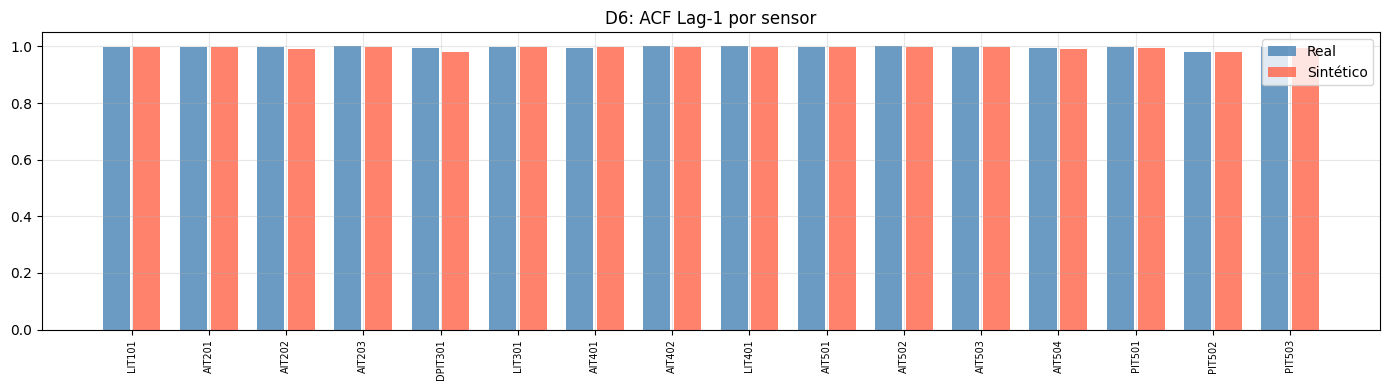

In [27]:
print("=== D6: DIAGNOSTICO TEMPORAL — AUTOCORRELACION INTRA-VENTANA ==="); print()
def acf1(windows_3d):
    x = windows_3d; lag0 = x[:,:-1,:]; lag1 = x[:,1:,:]
    return np.array([np.corrcoef(lag0[:,:,j].flatten(), lag1[:,:,j].flatten())[0,1]
                     for j in range(x.shape[2])])
acf_r = acf1(train_windows); acf_s = acf1(synth_qt_corrected); acf_d = np.abs(acf_r - acf_s)
print(f'{"Sensor":<20}  {"ACF1_real":>10}  {"ACF1_sint":>10}  {"diff":>8}  Estado')
print("-" * 60)
for j, s in enumerate(GAN_CONT_COLS):
    est = "OK" if acf_d[j]<0.10 else ("REVISAR" if acf_d[j]<0.25 else "MAL")
    print(f'{s:<20}  {acf_r[j]:>10.4f}  {acf_s[j]:>10.4f}  {acf_d[j]:>8.4f}  {est}')
print(f"\nACF1 diff media: {acf_d.mean():.4f}  (ideal: < 0.05)")
fig, ax = plt.subplots(figsize=(14, 4))
x_pos = np.arange(len(GAN_CONT_COLS))
ax.bar(x_pos-0.2, acf_r, 0.35, color="steelblue", alpha=0.8, label="Real")
ax.bar(x_pos+0.2, acf_s, 0.35, color="tomato",    alpha=0.8, label="Sintético")
ax.set_xticks(x_pos); ax.set_xticklabels([s.replace(".Pv","") for s in GAN_CONT_COLS], rotation=90, fontsize=7)
ax.set_ylim(0, 1.05); ax.set_title("D6: ACF Lag-1 por sensor"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 14. Síntesis final — Ensamblaje de datos sintéticos

Inverse transform → escala física → FITs empíricos → discretas empíricas →
escalado con scaler_cont del detector → formato LSTM-VAE `(N, T, C)`.


In [28]:
n_gan = len(GAN_CONT_COLS)
synth_qt_flat  = synth_qt_corrected.reshape(-1, n_gan)
synth_gan_phys = qt.inverse_transform(synth_qt_flat).reshape(synth_qt_clipped.shape)

def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)
    for j, col in enumerate(fit_cols):
        p0 = fit_empirical[col]["p_zero"]
        fo = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)
        for i in range(n_windows):
            state = 0 if rng.random() < p0 else 1
            for t in range(window_size):
                if rng.random() >= 0.97: state = 0 if rng.random() < p0 else 1
                windows[i,t,j] = 0.0 if state == 0 else float(rng.choice(fo))
    return windows

def synthesize_disc_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp = disc_empirical[col]; vals = list(emp.keys()); probs = list(emp.values())
        for i in range(n_windows):
            windows[i,0,j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                windows[i,t,j] = windows[i,t-1,j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
    return windows

synth_fit_raw  = synthesize_fit_windows(n_synth, WINDOW_SIZE, FIT_BIMODAL_COLS, fit_empirical, SEED)
synth_disc_raw = synthesize_disc_windows(n_synth, WINDOW_SIZE, DISCRETE_COLS, disc_empirical, SEED)

print("Verificación P(0) FITs sintetizados:")
for j, col in enumerate(FIT_BIMODAL_COLS):
    p0_real = fit_empirical[col]["p_zero"]; p0_synth = (synth_fit_raw[:,:,j] == 0.0).mean()
    ok = "✅" if abs(p0_real - p0_synth) < 0.02 else "⚠️"
    print(f"  {ok} {col}: real={p0_real:.3f}, sint={p0_synth:.3f}")


Verificación P(0) FITs sintetizados:
  ✅ FIT101: real=0.270, sint=0.271
  ✅ FIT201: real=0.247, sint=0.249
  ✅ FIT301: real=0.132, sint=0.133
  ✅ FIT401: real=0.000, sint=0.000
  ✅ FIT501: real=0.000, sint=0.000
  ✅ FIT502: real=0.000, sint=0.000
  ✅ FIT503: real=0.000, sint=0.000
  ✅ FIT504: real=0.000, sint=0.000
  ✅ FIT601: real=0.212, sint=0.213


In [29]:
# Construir array completo en orden del detector (CONTINUOUS_COLS)
synth_all_phys = np.zeros((n_synth, WINDOW_SIZE, len(CONTINUOUS_COLS)), dtype=np.float32)
for j, col in enumerate(GAN_CONT_COLS):
    synth_all_phys[:,:,CONTINUOUS_COLS.index(col)] = synth_gan_phys[:,:,j]
for j, col in enumerate(FIT_BIMODAL_COLS):
    if col in CONTINUOUS_COLS:
        synth_all_phys[:,:,CONTINUOUS_COLS.index(col)] = synth_fit_raw[:,:,j]

# Escalar con scaler_cont del detector (StandardScaler + clip)
synth_for_det = np.clip(
    scaler_cont.transform(
        pd.DataFrame(synth_all_phys.reshape(-1, len(CONTINUOUS_COLS)), columns=CONTINUOUS_COLS)
    ).reshape(synth_all_phys.shape),
    -CLIP_VAL, CLIP_VAL
)

def summarize_disc_windows_final(disc_raw, dcols):
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:,j]; s = pd.Series(v)
            feats[f"{col}__mode"]        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f"{col}__transitions"] = float(np.sum(v[1:] != v[:-1]))
            feats[f"{col}__nunique"]     = float(len(np.unique(v)))
            feats[f"{col}__dominance"]   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc_windows_final(synth_disc_raw, DISCRETE_COLS)

# ── Formato LSTM-VAE: (N, T, C) — sin transponer ──────────────────────────────
X_synth_cont = synth_for_det.astype(np.float32)           # (N, T, C)
X_synth_disc = synth_disc_summary.values.astype(np.float32)  # (N, disc_dim)

print("Shapes finales:")
print(f"  X_synth_cont (LSTM-VAE): {X_synth_cont.shape}  <- (N, T, C), SIN transponer")
print(f"  X_synth_disc (LSTM-VAE): {X_synth_disc.shape}  <- (N, disc_summary_dim)")
assert X_synth_cont.shape[1] == WINDOW_SIZE, "ERROR: T != WINDOW_SIZE"
assert X_synth_cont.shape[2] == len(CONTINUOUS_COLS), "ERROR: C != len(CONTINUOUS_COLS)"
assert X_synth_disc.shape[1] == DISC_DIM, f"ERROR: disc_dim {X_synth_disc.shape[1]} != {DISC_DIM}"
print("✅ Shapes OK — compatible con HybridLSTMVAE.forward(xc, xd)")


c:\Users\j.manriquec\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Shapes finales:
  X_synth_cont (LSTM-VAE): (59173, 60, 25)  <- (N, T, C), SIN transponer
  X_synth_disc (LSTM-VAE): (59173, 104)  <- (N, disc_summary_dim)
✅ Shapes OK — compatible con HybridLSTMVAE.forward(xc, xd)


## 15. Evaluación de calidad distribucional: PCA y t-SNE

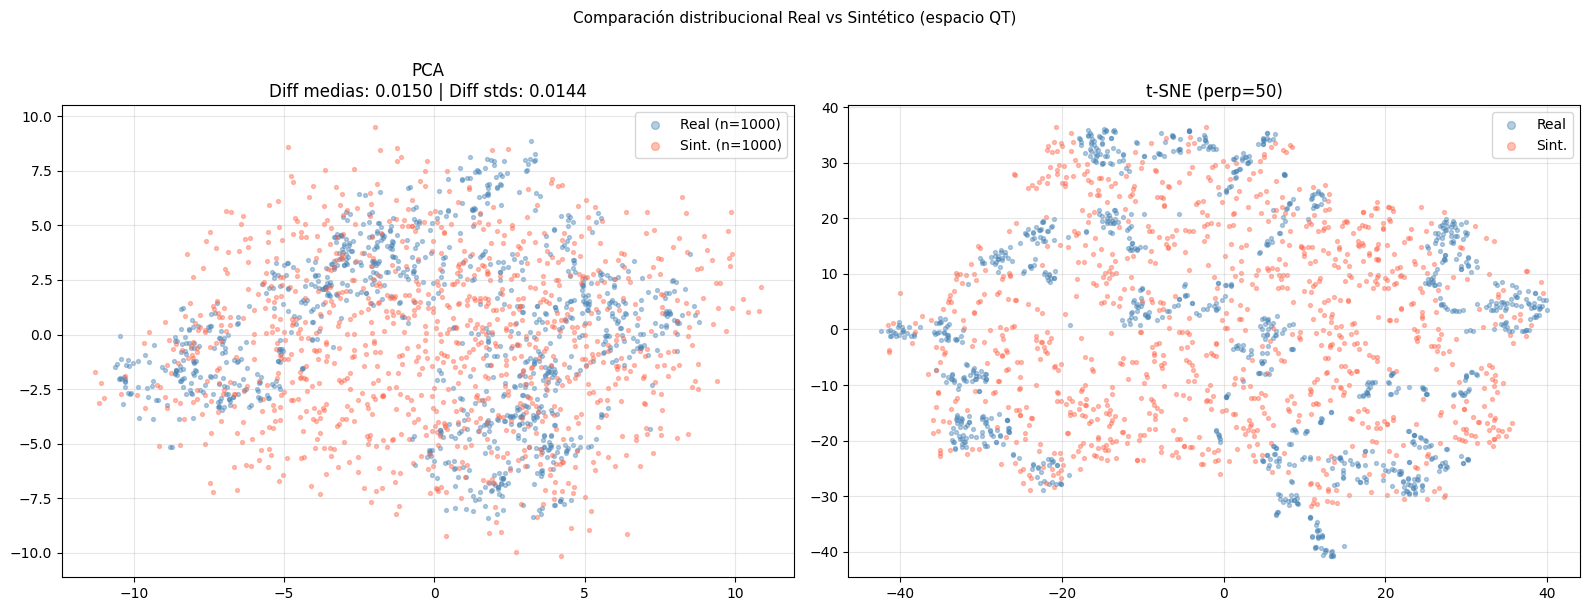

Diff medias: 0.0150  ✅
Diff stds:   0.0144  ✅


In [30]:
n_plot = min(1000, len(train_windows), n_synth)
rng    = np.random.default_rng(SEED)
ri     = rng.choice(len(train_windows), n_plot, replace=False)
si     = rng.choice(n_synth,            n_plot, replace=False)
real_s  = train_windows[ri].reshape(n_plot, -1)
synth_s = synth_qt_corrected[si].reshape(n_plot, -1)
md_diff = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd_diff = np.abs(real_s.std(0)  - synth_s.std(0)).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pca_v = PCA(n_components=2, random_state=SEED)
pr = pca_v.fit_transform(real_s); ps = pca_v.transform(synth_s)
axes[0].scatter(pr[:,0], pr[:,1], alpha=0.4, c="steelblue", s=8, label=f"Real (n={n_plot})")
axes[0].scatter(ps[:,0], ps[:,1], alpha=0.4, c="tomato",    s=8, label=f"Sint. (n={n_plot})")
axes[0].set_title(f"PCA\nDiff medias: {md_diff:.4f} | Diff stds: {sd_diff:.4f}")
axes[0].legend(markerscale=2); axes[0].grid(True, alpha=0.3)
comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s]))
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot,0], tout[:n_plot,1], alpha=0.4, c="steelblue", s=8, label="Real")
axes[1].scatter(tout[n_plot:,0], tout[n_plot:,1], alpha=0.4, c="tomato",    s=8, label="Sint.")
axes[1].set_title(f"t-SNE (perp={perp})"); axes[1].legend(markerscale=2); axes[1].grid(True, alpha=0.3)
plt.suptitle("Comparación distribucional Real vs Sintético (espacio QT)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(str(TIMEGAN_DIR / "tsne_pca.png"), dpi=150, bbox_inches="tight"); plt.show()
print(f"Diff medias: {md_diff:.4f}  {'✅' if md_diff<0.10 else '⚠️'}")
print(f"Diff stds:   {sd_diff:.4f}  {'✅' if sd_diff<0.10 else '⚠️'}")


In [31]:
# Tabla resumen de calidad por sensor
print("=== RESUMEN DE CALIDAD POR SENSOR (espacio QT) ==="); print()
real_flat  = train_windows.reshape(-1, len(GAN_CONT_COLS))
synth_flat = synth_qt_corrected.reshape(-1, len(GAN_CONT_COLS))
print(f'{"Sensor":<20} {"dm":>8} {"ds":>8}  Estado')
print("-" * 45)
quality_rows = []
for j, col in enumerate(GAN_CONT_COLS):
    mr,ms = real_flat[:,j].mean(), synth_flat[:,j].mean()
    sr,ss = real_flat[:,j].std(),  synth_flat[:,j].std()
    dm,ds = abs(mr-ms), abs(sr-ss)
    status = "EXCELENTE" if dm<0.03 and ds<0.03 else "BUENO" if dm<0.07 and ds<0.07 else              "MODERADO" if dm<0.12 else "REVISAR"
    print(f'{col:<20} {dm:>8.4f} {ds:>8.4f}  {status}')
    quality_rows.append({"sensor":col,"diff_mean":dm,"diff_std":ds,"status":status})
quality_df = pd.DataFrame(quality_rows)
print(f"\nDiff medias global: {quality_df['diff_mean'].mean():.4f}")


=== RESUMEN DE CALIDAD POR SENSOR (espacio QT) ===

Sensor                     dm       ds  Estado
---------------------------------------------
LIT101                 0.0000   0.0157  EXCELENTE
AIT201                 0.0000   0.0054  EXCELENTE
AIT202                 0.0000   0.0140  EXCELENTE
AIT203                 0.0000   0.0280  EXCELENTE
DPIT301                0.0000   0.0000  EXCELENTE
LIT301                 0.0000   0.0150  EXCELENTE
AIT401                 0.0000   0.0405  BUENO
AIT402                 0.0000   0.0101  EXCELENTE
LIT401                 0.0000   0.0336  BUENO
AIT501                 0.0000   0.0060  EXCELENTE
AIT502                 0.0000   0.0054  EXCELENTE
AIT503                 0.0000   0.0146  EXCELENTE
AIT504                 0.0000   0.0008  EXCELENTE
PIT501                 0.0000   0.0021  EXCELENTE
PIT502                 0.0000   0.0004  EXCELENTE
PIT503                 0.0000   0.0024  EXCELENTE

Diff medias global: 0.0000


In [32]:
# AUC del RandomForest (referencial — el TSTR es la métrica definitiva)
X_all = np.vstack([real_s, synth_s]); y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr_rf, y_tr_rf)
auc = roc_auc_score(y_te_rf, clf.predict_proba(X_te_rf)[:,1])
fi = clf.feature_importances_; max_fi = fi.max()
print(f"AUC discriminabilidad = {auc:.4f}  (referencial)")
print(f"Importancia máxima RF: {max_fi:.4f}  {'✅' if max_fi<0.05 else '⚠️'}")
print("NOTA: el TSTR es la métrica definitiva, no el AUC del RF.")


AUC discriminabilidad = 0.9987  (referencial)
Importancia máxima RF: 0.0322  ✅
NOTA: el TSTR es la métrica definitiva, no el AUC del RF.


## 16. Guardar artefactos

In [33]:
for name, model in [("embedder",embedder),("recovery",recovery),("generator",generator),
                    ("supervisor",supervisor),("discriminator",discriminator)]:
    torch.save(model.state_dict(), TIMEGAN_DIR / f"{name}.pt")

joblib.dump(qt, ARTIFACTS_DIR / "timegan_quantile_transformer.pkl")

with open(TIMEGAN_DIR / "fit_empirical.json", "w") as f:
    json.dump({col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
               for col, v in fit_empirical.items()}, f, indent=2)
with open(TIMEGAN_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()}
               for k,v in disc_empirical.items()}, f, indent=2)
with open(TIMEGAN_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k,vs in discrete_value_maps.items()}, f, indent=2)

np.save(TIMEGAN_DIR / "synth_qt_raw.npy",       synth_qt_clipped)
np.save(TIMEGAN_DIR / "synth_qt.npy",           synth_qt_corrected)
np.save(TIMEGAN_DIR / "synth_gan_physical.npy", synth_gan_phys)
np.save(TIMEGAN_DIR / "synth_fit_raw.npy",      synth_fit_raw)
np.save(TIMEGAN_DIR / "synth_all_physical.npy", synth_all_phys)
np.save(TIMEGAN_DIR / "synth_for_detector.npy", synth_for_det)
np.save(TIMEGAN_DIR / "X_synth_cont.npy", X_synth_cont)  # (N, T, C) — listo para LSTM-VAE
np.save(TIMEGAN_DIR / "X_synth_disc.npy", X_synth_disc)  # (N, disc_dim)
np.save(TIMEGAN_DIR / "synth_disc_raw.npy", synth_disc_raw)
synth_disc_summary.to_csv(TIMEGAN_DIR / "synth_disc_summary.csv", index=False)
quality_df.to_csv(TIMEGAN_DIR / "sensor_quality_summary.csv", index=False)

config = {
    "version":           "a1a2_timegan_v1_lstmvae",
    "detector_target":   "lstm_vae_swat_a1a2_baseline_v2",
    "synth_cont_format": "(N, T, C) — NO transponer — LSTM-VAE",
    "dataset":           "SWaT A1/A2 Dec 2015 — Normal_v1",
    "source_a12":        "Basado en TimeGAN A12 v18 (misma arquitectura)",
    "window_size":       WINDOW_SIZE,
    "stride_timegan":    TIMEGAN_STRIDE,
    "qt_clip":           [QT_CLIP_LO, QT_CLIP_HI],
    "warmup_sec":        WARMUP_SEC,
    "gan_cont_cols":     GAN_CONT_COLS,
    "fit_bimodal_cols":  FIT_BIMODAL_COLS,
    "discrete_cols":     DISCRETE_COLS,
    "continuous_cols":   CONTINUOUS_COLS,
    "feature_dim":       feature_dim,
    "hidden_dim":        hidden_dim,
    "latent_dim":        latent_dim,
    "num_layers":        num_layers,
    "G_STEPS": G_STEPS, "D_STEPS": D_STEPS, "G_CLIP": G_CLIP, "D_CLIP": D_CLIP,
    "R1_LAMBDA": R1_LAMBDA, "R1_INTERVAL": R1_INTERVAL,
    "gamma": gamma, "eta": eta, "FM_W": FM_W,
    "epochs_embedder":     epochs_embedder,
    "epochs_supervisor":   epochs_supervisor,
    "epochs_joint":        epochs_joint,
    "gen_pretrain_epochs": GEN_PRETRAIN_EPOCHS,
    "batch_size":          BATCH_SIZE,
    "total_train_windows": int(len(train_windows)),
    "n_synth_windows":     n_synth,
    "metrics": {
        "embedder_mse_final":      float(embedder_history[-1]),
        "supervisor_loss_final":   float(supervisor_history[-1]),
        "gen_pretrain_knn_final":  float(pretrain_history[-1]),
        "g_loss_initial":          float(joint_g_history[0]),
        "g_loss_final":            float(joint_g_history[-1]),
        "d_loss_final":            float(joint_d_history[-1]),
        "spikes_g35":              int(sum(1 for g in joint_g_history if g > 3.5)),
        "diff_medias_qt_post_qm":  float(md_diff),
        "diff_stds_qt_post_qm":    float(sd_diff),
        "sensors_corrected":       len(CORRECTION_SENSORS),
        "auc_rf":                  float(auc),
        "rf_importancia_max":      float(max_fi),
    }
}
with open(TIMEGAN_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

pd.DataFrame({"epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history,
}).to_csv(TIMEGAN_DIR / "training_history.csv", index=False)

print("Artefactos guardados en:", TIMEGAN_DIR.resolve())
print()
print(f"  Train windows: {len(train_windows):,} | Batches/época: {len(train_loader)}")
print(f"  Embedder MSE:  {embedder_history[-1]:.6f}")
print(f"  G final:       {joint_g_history[-1]:.4f}  (Nash: {nash_g:.4f})")
print(f"  D final:       {joint_d_history[-1]:.4f}  (Nash: {nash_d:.4f})")
print(f"  Spikes G>3.5:  {int(sum(1 for g in joint_g_history if g > 3.5))}")
print(f"  diff_medias:   {md_diff:.4f}")
print(f"  X_synth_cont:  {X_synth_cont.shape}  (N, T, C) — LSTM-VAE ready")
print(f"  X_synth_disc:  {X_synth_disc.shape}")
for fp_ in sorted(TIMEGAN_DIR.iterdir()):
    sz = fp_.stat().st_size
    print(f"  {fp_.name:<40} {sz/1e3 if sz<1e6 else sz/1e6:6.1f} {'KB' if sz<1e6 else 'MB'}")


Artefactos guardados en: C:\Users\j.manriquec\ics-synthetic-data-augmentation\models\timegan\lstm_vae_a1a2_baseline_v2_v1

  Train windows: 59,173 | Batches/época: 462
  Embedder MSE:  0.012619
  G final:       10.3051  (Nash: 1.3863)
  D final:       1.2929  (Nash: 2.0794)
  Spikes G>3.5:  1981
  diff_medias:   0.0150
  X_synth_cont:  (59173, 60, 25)  (N, T, C) — LSTM-VAE ready
  X_synth_disc:  (59173, 104)
  config.json                                 3.0 KB
  disc_empirical.json                         1.6 KB
  discrete_value_maps.json                    0.9 KB
  discriminator.pt                            1.2 MB
  embedder.pt                                 1.1 MB
  fit_empirical.json                         79.9 KB
  generator.pt                                1.2 MB
  recovery.pt                                 1.2 MB
  sensor_quality_summary.csv                  0.7 KB
  supervisor.pt                             861.5 KB
  synth_all_physical.npy                    355.0 MB
  syn